# **LoanTap Logistic Regression Case Study:**

# **About LoanTap**:

LoanTap is an online platform committed to delivering customized loan products to millennials. They innovate in an otherwise dull loan segment, to deliver instant, flexible loans on consumer friendly terms to salaried professionals and businessmen.

The data science team at LoanTap is building an underwriting layer to determine the creditworthiness of MSMEs as well as individuals. LoanTap deploys formal credit to salaried individuals and businesses 4 main financial instruments:

- Personal Loan
- EMI Free Loan
- Personal Overdraft
- Advance Salary Loan

This case study will focus on the underwriting process behind Personal Loan only.

# **Problem Statement:**

Given a set of attributes for an Individual, determine if a credit line should be extended to them. If so, what should the repayment terms be in business recommendations?

# **Dataset Data dictionary:**

- **loan_amnt:** The listed amount of the loan applied for by the borrower. If at some point in time, the credit department reduces the loan amount, then it will be reflected in this value.

- **term:** The number of payments on the loan. Values are in months and can be either 36 or 60.

- **int_rate:** Interest Rate on the loan

- **installment:** The monthly payment owed by the borrower if the loan originates.

- **grade:** LoanTap assigned loan grade

- **sub_grade:** LoanTap assigned loan subgrade

- **emp_title:** The job title supplied by the Borrower when applying for the loan.

- **emp_length:** Employment length in years. Possible values are between 0 and 10 where 0 means less than one year and 10 means ten or more years.

- **home_ownership:** The home ownership status provided by the borrower during registration or obtained from the credit report.

- **annual_inc:** The self-reported annual income provided by the borrower during registration.

- **verification_status:** Indicates if income was verified by LoanTap, not verified, or if the income source was verified

- **issue_d:** The month which the loan was funded

- **loan_status:** Current status of the loan - Target Variable

- **purpose:** A category provided by the borrower for the loan request.

- **title:** The loan title provided by the borrower

- **dti:** A ratio calculated using the borrower’s total monthly debt payments on the total debt obligations, excluding mortgage and the requested LoanTap loan, divided by the borrower’s self-reported monthly income.

- **earliest_cr_line:** The month the borrower's earliest reported credit line was opened

- **open_acc:** The number of open credit lines in the borrower's credit file.

- **pub_rec:** Number of derogatory public records

- **revol_bal:** Total credit revolving balance

- **revol_util:** Revolving line utilization rate, or the amount of credit the borrower is using relative to all available revolving credit.

- **total_acc:** The total number of credit lines currently in the borrower's credit file

- **initial_list_status:** The initial listing status of the loan. Possible values are – W, F

- **application_type:** Indicates whether the loan is an individual application or a joint application with two co-borrowers

- **mort_acc:** Number of mortgage accounts.

- **pub_rec_bankruptcies:** Number of public record bankruptcies

- **Address:** Address of the individual

# **Concepts Used:**

- Exploratory Data Analysis
- Feature Engineering
- Logistic Regression
- Precision Vs Recall Tradeoff

# **Part A: Importing the dataset and understanding the structure:**

In [1]:
# Import all the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.graph_objects as go
warnings.filterwarnings('ignore')

In [2]:
# Read the Aerofit dataset and create a dataframe for analysis. Print the first 5 rows
df = pd.read_csv("/content/drive/MyDrive/Datasets/LoanTap.csv")
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


In [3]:
# Print the last 5 rows
df.tail()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
396025,10000.0,60 months,10.99,217.38,B,B4,licensed bankere,2 years,RENT,40000.0,...,6.0,0.0,1990.0,34.3,23.0,w,INDIVIDUAL,0.0,0.0,"12951 Williams Crossing\r\nJohnnyville, DC 30723"
396026,21000.0,36 months,12.29,700.42,C,C1,Agent,5 years,MORTGAGE,110000.0,...,6.0,0.0,43263.0,95.7,8.0,f,INDIVIDUAL,1.0,0.0,"0114 Fowler Field Suite 028\r\nRachelborough, ..."
396027,5000.0,36 months,9.99,161.32,B,B1,City Carrier,10+ years,RENT,56500.0,...,15.0,0.0,32704.0,66.9,23.0,f,INDIVIDUAL,0.0,0.0,"953 Matthew Points Suite 414\r\nReedfort, NY 7..."
396028,21000.0,60 months,15.31,503.02,C,C2,"Gracon Services, Inc",10+ years,MORTGAGE,64000.0,...,9.0,0.0,15704.0,53.8,20.0,f,INDIVIDUAL,5.0,0.0,"7843 Blake Freeway Apt. 229\r\nNew Michael, FL..."
396029,2000.0,36 months,13.61,67.98,C,C2,Internal Revenue Service,10+ years,RENT,42996.0,...,3.0,0.0,4292.0,91.3,19.0,f,INDIVIDUAL,NaN,0.0,"787 Michelle Causeway\r\nBriannaton, AR 48052"


In [4]:
# Print the shape of the dataframe
df.shape

(396030, 27)

### **The dataset has 3,96,030 records with 27 features.**

In [5]:
# Statistical summary of the numerical columns of the dataframe
df.describe()

,loan_amnt,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
count,396030.000000,396030.000000,396030.000000,3.960300e+05,396030.000000,396030.000000,396030.000000,3.960300e+05,395754.000000,396030.000000,358235.000000,395495.000000
mean,14113.888089,13.639400,431.849698,7.420318e+04,17.379514,11.311153,0.178191,1.584454e+04,53.791749,25.414744,1.813991,0.121648
std,8357.441341,4.472157,250.727790,6.163762e+04,18.019092,5.137649,0.530671,2.059184e+04,24.452193,11.886991,2.147930,0.356174
min,500.000000,5.320000,16.080000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,2.000000,0.000000,0.000000
25%,8000.000000,10.490000,250.330000,4.500000e+04,11.280000,8.000000,0.000000,6.025000e+03,35.800000,17.000000,0.000000,0.000000
50%,12000.000000,13.330000,375.430000,6.400000e+04,16.910000,10.000000,0.000000,1.118100e+04,54.800000,24.000000,1.000000,0.000000
75%,20000.000000,16.490000,567.300000,9.000000e+04,22.980000,14.000000,0.000000,1.962000e+04,72.900000,32.000000,3.000000,0.000000
max,40000.000000,30.990000,1533.810000,8.706582e+06,9999.000000,90.000000,86.000000,1.743266e+06,892.300000,151.000000,34.000000,8.000000


In [6]:
# Data type of the attributes of the dataframe
df.dtypes

,0
loan_amnt,float64
term,object
int_rate,float64
installment,float64
grade,object
sub_grade,object
emp_title,object
emp_length,object
home_ownership,object
annual_inc,float64


In [7]:
# Info on the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

In [8]:
df.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'purpose', 'title',
       'dti', 'earliest_cr_line', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'application_type',
       'mort_acc', 'pub_rec_bankruptcies', 'address'],
      dtype='object')

In [9]:
df.keys()

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'purpose', 'title',
       'dti', 'earliest_cr_line', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'application_type',
       'mort_acc', 'pub_rec_bankruptcies', 'address'],
      dtype='object')

In [10]:
df.nunique()

,0
loan_amnt,1397
term,2
int_rate,566
installment,55706
grade,7
sub_grade,35
emp_title,173105
emp_length,11
home_ownership,6
annual_inc,27197


In [11]:
# Check for duplicate values
df.duplicated().sum()

np.int64(0)

In [12]:
# Distribution of Target Variable
df['loan_status'].value_counts()

,count
loan_status,
Fully Paid,318357
Charged Off,77673


In [13]:
# Distribution of Target Variable
np.round(df['loan_status'].value_counts(normalize = True),4)

,proportion
loan_status,
Fully Paid,0.8039
Charged Off,0.1961


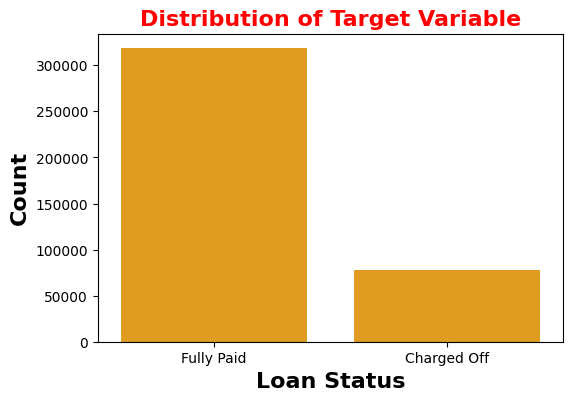

In [14]:
# Target variable distribution
plt.figure(figsize = (6,4))
sns.countplot(x = df['loan_status'], color = 'orange')
plt.title('Distribution of Target Variable', fontsize = 16, fontweight = 'bold', color = 'red')
plt.xlabel('Loan Status', fontsize = 16, fontweight = 'bold')
plt.ylabel('Count', fontsize = 16, fontweight = 'bold')
plt.show()

## **Since the target variable loan_status is imbalanced (~80% Fully Paid vs ~20% Charged Off), accuracy is not a reliable evaluation metric, because a naive model predicting “Fully Paid” for all customers would still achieve ~80% accuracy without actually identifying defaulters.**

# **Modeling Approach:**

A structured three-step approach is followed to build and evaluate the logistic regression model:

1. **Baseline Model**  
   - Logistic Regression trained on the **original imbalanced dataset** (no handling of class imbalance).  
   - This establishes benchmark performance.  
   - Primary evaluation metrics: **Recall**, **Precision**, **F1-score** (for Charged Off class), **ROC-AUC**, and **PR-AUC** (accuracy is not prioritized due to imbalance).

2. **Improved Models with Imbalance Handling**  
   Two techniques are applied to improve detection of the minority class (Charged Off):  
   - **Class-weight balanced**: Algorithmic adjustment (weights inversely proportional to class frequencies).  
   - **SMOTE**: Synthetic oversampling of the minority class (applied **only to training data** to avoid leakage).  

3. **Goal & Evaluation Focus**  
   - The primary objective is to **increase recall for Charged Off** (detect more real defaulters) while maintaining reasonable precision (limit false positives / rejected good borrowers).
   - Business priority: Minimize NPAs (costly false negatives) while maximizing lending opportunities (avoid excessive false positives).

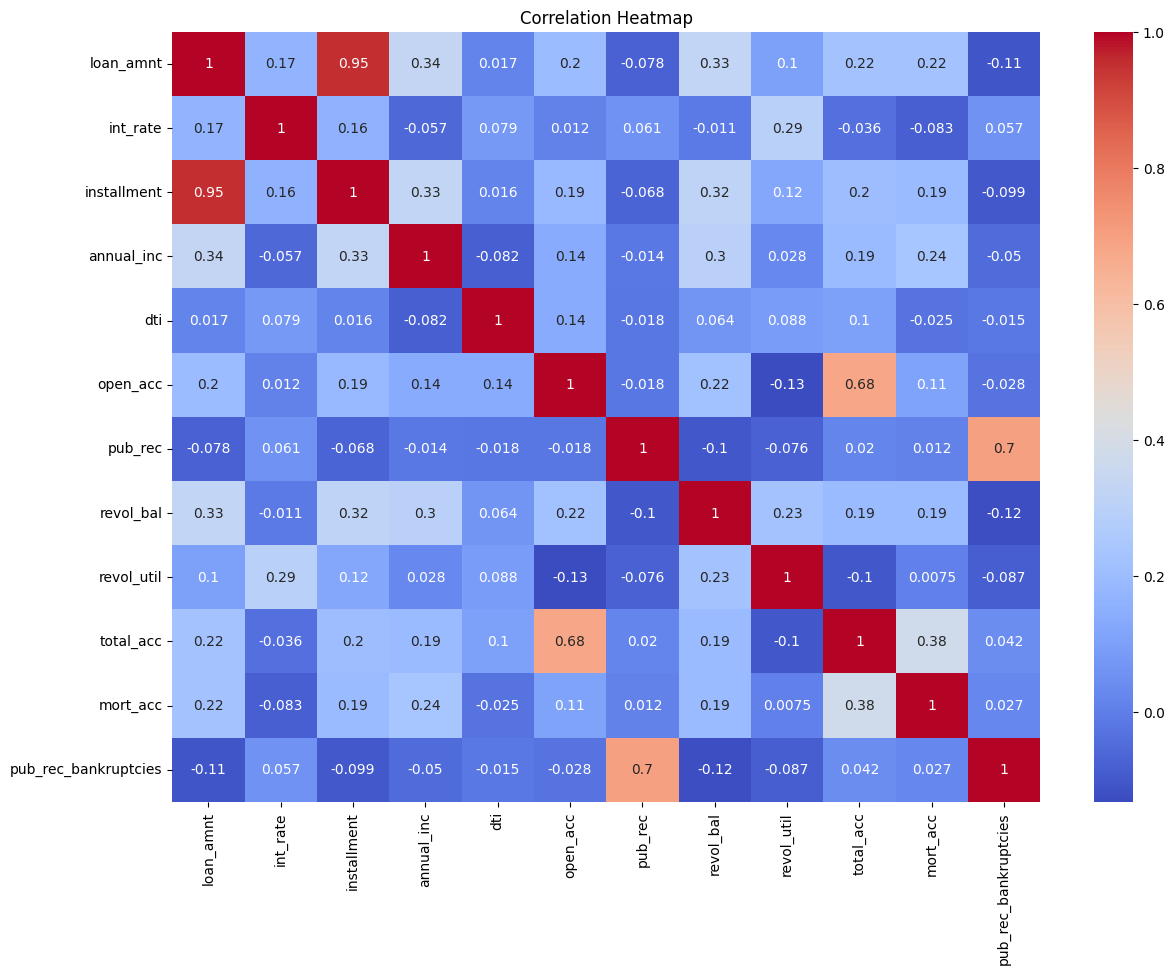

In [15]:
# Heatmap for correlation
plt.figure(figsize = (14,10))
sns.heatmap(df.corr(numeric_only = True), annot = True, cmap = 'coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### **The correlation heatmap shows:**
- **installment and loan_amnt are highly correlated (r ≈ 0.95), which is expected since installment is derived from loan amount and loan term. This indicates strong multicollinearity, so keeping both may reduce coefficient interpretability in Logistic Regression. Better to drop either loan_amt or installment.**

- **open_acc and total_acc are moderately correlated (r ≈ 0.68), suggesting customers with more total accounts also tend to have more open accounts. Both features capture related aspects of credit history. Better to keep both features or create a ratio (open_to_total_acc = open_acc / total_acc).**

- **pub_rec and pub_rec_bankruptcies are moderately correlated (r ≈ 0.70), indicating that borrowers with public records are also more likely to have bankruptcies, reflecting a shared underlying risk behavior. Better to retain pub_rec_bankruptcies since it is a stronger credit-event feature.**

## **Drop:**

✅ installment

✅ pub_rec

## **Keep:**

✅ loan_amt

✅ open_acc

✅ total_acc

✅ pub_rec_bankruptcies

# **Part B: Data Pre-Processing:**

In [16]:
# Check for missing values and their percentage
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Combine into a dataFrame for better readability
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_percentage})
missing_df

,Missing Values,Percentage (%)
loan_amnt,0,0.000000
term,0,0.000000
int_rate,0,0.000000
installment,0,0.000000
grade,0,0.000000
sub_grade,0,0.000000
emp_title,22927,5.789208
emp_length,18301,4.621115
home_ownership,0,0.000000
annual_inc,0,0.000000


- mort_acc ~ 9.54% missing (highest)

- emp_title ~ 5.79% missing

- emp_length ~ 4.62% missing

- title ~ 0.44% missing

- pub_rec_bankruptcies ~ 0.135% missing

- revol_util ~ 0.07% missing

- Other features have 0% data missing

In [17]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


In [18]:
df.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'purpose', 'title',
       'dti', 'earliest_cr_line', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'application_type',
       'mort_acc', 'pub_rec_bankruptcies', 'address'],
      dtype='object')

In [19]:
df['term'] = df['term'].str.extract('(\d+)').astype(int)
df['term'].value_counts()

,count
term,
36,302005
60,94025


In [20]:
df['grade'].value_counts()

,count
grade,
B,116018
C,105987
A,64187
D,63524
E,31488
F,11772
G,3054


In [21]:
df['sub_grade'].value_counts()

,count
sub_grade,
B3,26655
B4,25601
C1,23662
C2,22580
B2,22495
B5,22085
C3,21221
C4,20280
B1,19182


In [22]:
df['emp_title'].value_counts()

,count
emp_title,
Teacher,4389
Manager,4250
Registered Nurse,1856
RN,1846
Supervisor,1830
...,...
OMIV Supervisor,1
"SVP, Technology",1
sikorsky,1


In [23]:
df['emp_length'].value_counts()

,count
emp_length,
10+ years,126041
2 years,35827
< 1 year,31725
3 years,31665
5 years,26495
1 year,25882
4 years,23952
6 years,20841
7 years,20819


In [24]:
df['emp_length'] = df['emp_length'].replace({'10+ years': '10 years', '< 1 year': '0 years'})
df['emp_length'] = df['emp_length'].str.extract('(\d+)').astype(float)
df['emp_length'].value_counts()

,count
emp_length,
10.0,126041
2.0,35827
0.0,31725
3.0,31665
5.0,26495
1.0,25882
4.0,23952
6.0,20841
7.0,20819


In [25]:
df['home_ownership'].value_counts()

,count
home_ownership,
MORTGAGE,198348
RENT,159790
OWN,37746
OTHER,112
NONE,31
ANY,3


## **OTHER, NONE and ANY can be combined into a single category of OTHER.**

In [26]:
df.loc[(df['home_ownership']=='NONE') |(df['home_ownership']=='ANY'),'home_ownership']='OTHER'
df['home_ownership'].value_counts()

,count
home_ownership,
MORTGAGE,198348
RENT,159790
OWN,37746
OTHER,146


In [27]:
df['verification_status'].value_counts()

,count
verification_status,
Verified,139563
Source Verified,131385
Not Verified,125082


In [28]:
df['purpose'].value_counts()

,count
purpose,
debt_consolidation,234507
credit_card,83019
home_improvement,24030
other,21185
major_purchase,8790
small_business,5701
car,4697
medical,4196
moving,2854


In [29]:
df['title'].value_counts()

,count
title,
Debt consolidation,152472
Credit card refinancing,51487
Home improvement,15264
Other,12930
Debt Consolidation,11608
...,...
creditcardrefi,1
Debt/Home,1
Peace Of Mind Loan,1


## **Purpose is a controlled category (low cardinality) and title is free-text (high cardinality), often derived from purpose-like text. Hence, keep purpose (strong feature), purpose has manageable categories and is useful.**

In [30]:
df['dti'].value_counts()

,count
dti,
0.00,313
14.40,310
19.20,302
16.80,301
18.00,300
...,...
47.05,1
46.52,1
1622.00,1


In [31]:
df['initial_list_status'].value_counts()

,count
initial_list_status,
f,238066
w,157964


In [32]:
df['initial_list_status'] = df['initial_list_status'].replace({'f': 'F', 'w': 'W'})
df['initial_list_status'].value_counts()

,count
initial_list_status,
F,238066
W,157964


In [33]:
df['application_type'].value_counts()

,count
application_type,
INDIVIDUAL,395319
JOINT,425
DIRECT_PAY,286


In [34]:
df['issue_d']

,issue_d
0,Jan-2015
1,Jan-2015
2,Jan-2015
3,Nov-2014
4,Apr-2013
...,...
396025,Oct-2015
396026,Feb-2015
396027,Oct-2013
396028,Aug-2012


In [35]:
df['earliest_cr_line']

,earliest_cr_line
0,Jun-1990
1,Jul-2004
2,Aug-2007
3,Sep-2006
4,Mar-1999
...,...
396025,Nov-2004
396026,Feb-2006
396027,Mar-1997
396028,Nov-1990


In [36]:
# Extract Month and Year on which loan was funded
# Converting issue_d to datetime first
df['issue_d'] = pd.to_datetime(df['issue_d'])
df['issue_d_month'] = df['issue_d'].dt.month
df['issue_d_year'] = df['issue_d'].dt.year

# Converting issue_d_year as numeric
df['issue_d_year'] = df['issue_d_year'].astype(int)

In [37]:
# Extract the Month on which the borrower's earliest reported credit line was opened
# Converting earliest_cr_line to datetime first
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'])
df['earliest_cr_line_month'] = df['earliest_cr_line'].dt.month
df['earliest_cr_line_year'] = df['earliest_cr_line'].dt.year

# Converting earliest_cr_line_year as numeric
df['earliest_cr_line_year'] = df['earliest_cr_line_year'].astype(int)

In [38]:
df['address']

,address
0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,"679 Luna Roads\r\nGreggshire, VA 11650"
...,...
396025,"12951 Williams Crossing\r\nJohnnyville, DC 30723"
396026,"0114 Fowler Field Suite 028\r\nRachelborough, ..."
396027,"953 Matthew Points Suite 414\r\nReedfort, NY 7..."
396028,"7843 Blake Freeway Apt. 229\r\nNew Michael, FL..."


In [39]:
# Feature Engineering: Extract State from the address feature
df['state'] = df['address'].apply(lambda x:x[-8:-6])
df['state']

,state
0,OK
1,SD
2,WV
3,MA
4,VA
...,...
396025,DC
396026,LA
396027,NY
396028,FL


In [40]:
# Coverting the categorical features into the category type
cat_cols = ['grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose', 'initial_list_status', 'application_type',
            'earliest_cr_line_month', 'issue_d_month', 'state']

for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

In [41]:
# Ensure numeric columns are actually numeric
num_cols = ['loan_amnt', 'term', 'int_rate', 'emp_length', 'annual_inc', 'dti', 'open_acc', 'revol_bal', 'revol_util',
            'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'issue_d_year', 'earliest_cr_line_year']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors = 'coerce')

# **Part C: Questionnaire: (Q1-Q5)**

### **Q1: What percentage of customers have fully paid their Loan Amount?**

In [42]:
(df['loan_status'].value_counts(normalize = True) * 100).round(2)

,proportion
loan_status,
Fully Paid,80.39
Charged Off,19.61


### **Q2: Comment about the correlation between Loan Amount and Installment features.**

In [43]:
df[['loan_amnt','installment']].corr()

,loan_amnt,installment
loan_amnt,1.000000,0.953929
installment,0.953929,1.000000


### **Q3: The majority of people have home ownership as?**

In [44]:
df['home_ownership'].value_counts().idxmax()

'MORTGAGE'

In [45]:
# Alternative way
df['home_ownership'].value_counts()

,count
home_ownership,
MORTGAGE,198348
RENT,159790
OWN,37746
OTHER,146


### **Q4: People with grades ‘A’ are more likely to fully pay their loan. (T/F)**

In [46]:
df.groupby('grade')['loan_status'].value_counts(normalize = True)

grade  loan_status
A      Fully Paid     0.937121
       Charged Off    0.062879
B      Fully Paid     0.874270
       Charged Off    0.125730
C      Fully Paid     0.788191
       Charged Off    0.211809
D      Fully Paid     0.711322
       Charged Off    0.288678
E      Fully Paid     0.626366
       Charged Off    0.373634
F      Fully Paid     0.572120
       Charged Off    0.427880
G      Fully Paid     0.521611
       Charged Off    0.478389
Name: proportion, dtype: float64

In [47]:
# Alternative way
pd.crosstab(df['grade'], df['loan_status'], normalize = 'index')

loan_status,Charged Off,Fully Paid
grade,,
A,0.062879,0.937121
B,0.125730,0.874270
C,0.211809,0.788191
D,0.288678,0.711322
E,0.373634,0.626366
F,0.427880,0.572120
G,0.478389,0.521611


### **Q5: Name the top 2 afforded job titles.**

In [48]:
df['emp_title'].value_counts().head(2)

,count
emp_title,
Teacher,4389
Manager,4250


In [49]:
# Alternative way
df[df['loan_status'] == 'Fully Paid']['emp_title'].value_counts().head(2)

,count
emp_title,
Teacher,3532
Manager,3321


### **1. Around 80% customers have fully paid their loan amount.**
### **2. installment and loan_amnt are highly correlated (r ≈ 0.95), which is expected since installment is derived from loan amount and loan term.**
### **3. The majority of people have home ownership as Mortgage.**
### **4. People with grades ‘A’ are more likely to fully pay their loan.**
### **5. The top 2 afforded job titles are Teacher and Manager.**

# **Part D: Data Preparation:**

In [50]:
# Drop redundant features
drop_cols = ['emp_title', 'title', 'address', 'issue_d', 'earliest_cr_line', 'installment', 'pub_rec']
df = df.drop(columns = drop_cols, axis = 1)

In [51]:
df.head()

,loan_amnt,term,int_rate,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,loan_status,...,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,issue_d_month,issue_d_year,earliest_cr_line_month,earliest_cr_line_year,state
0,10000.0,36,11.44,B,B4,10.0,RENT,117000.0,Not Verified,Fully Paid,...,25.0,W,INDIVIDUAL,0.0,0.0,1,2015,6,1990,OK
1,8000.0,36,11.99,B,B5,4.0,MORTGAGE,65000.0,Not Verified,Fully Paid,...,27.0,F,INDIVIDUAL,3.0,0.0,1,2015,7,2004,SD
2,15600.0,36,10.49,B,B3,0.0,RENT,43057.0,Source Verified,Fully Paid,...,26.0,F,INDIVIDUAL,0.0,0.0,1,2015,8,2007,WV
3,7200.0,36,6.49,A,A2,6.0,RENT,54000.0,Not Verified,Fully Paid,...,13.0,F,INDIVIDUAL,0.0,0.0,11,2014,9,2006,MA
4,24375.0,60,17.27,C,C5,9.0,MORTGAGE,55000.0,Verified,Charged Off,...,43.0,F,INDIVIDUAL,1.0,0.0,4,2013,3,1999,VA


In [52]:
df.dtypes

,0
loan_amnt,float64
term,int64
int_rate,float64
grade,category
sub_grade,category
emp_length,float64
home_ownership,category
annual_inc,float64
verification_status,category
loan_status,object


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 25 columns):
 #   Column                  Non-Null Count   Dtype   
---  ------                  --------------   -----   
 0   loan_amnt               396030 non-null  float64 
 1   term                    396030 non-null  int64   
 2   int_rate                396030 non-null  float64 
 3   grade                   396030 non-null  category
 4   sub_grade               396030 non-null  category
 5   emp_length              377729 non-null  float64 
 6   home_ownership          396030 non-null  category
 7   annual_inc              396030 non-null  float64 
 8   verification_status     396030 non-null  category
 9   loan_status             396030 non-null  object  
 10  purpose                 396030 non-null  category
 11  dti                     396030 non-null  float64 
 12  open_acc                396030 non-null  float64 
 13  revol_bal               396030 non-null  float64 
 14  revo

In [54]:
df.columns

Index(['loan_amnt', 'term', 'int_rate', 'grade', 'sub_grade', 'emp_length',
       'home_ownership', 'annual_inc', 'verification_status', 'loan_status',
       'purpose', 'dti', 'open_acc', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'application_type', 'mort_acc',
       'pub_rec_bankruptcies', 'issue_d_month', 'issue_d_year',
       'earliest_cr_line_month', 'earliest_cr_line_year', 'state'],
      dtype='object')

# **Sanity check on the columns:**

## **We have:**

- **Numeric:** loan_amnt, term, int_rate, emp_length, annual_inc, dti, open_acc, revol_bal, revol_util, total_acc, mort_acc, pub_rec_bankruptcies, issue_d_year, earliest_cr_line_year.

- **Categorical:** grade, sub_grade, home_ownership, verification_status, purpose, initial_list_status, application_type, issue_d_month, earliest_cr_line_month, state

- **Target:** loan_status

In [55]:
# Credit history length for future analysis
# df['credit_hist_years'] = df['issue_d_year'] - df['earliest_cr_line_year']

# **Part E: Exploratory Data Analysis:**

In [56]:
df.head()

,loan_amnt,term,int_rate,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,loan_status,...,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,issue_d_month,issue_d_year,earliest_cr_line_month,earliest_cr_line_year,state
0,10000.0,36,11.44,B,B4,10.0,RENT,117000.0,Not Verified,Fully Paid,...,25.0,W,INDIVIDUAL,0.0,0.0,1,2015,6,1990,OK
1,8000.0,36,11.99,B,B5,4.0,MORTGAGE,65000.0,Not Verified,Fully Paid,...,27.0,F,INDIVIDUAL,3.0,0.0,1,2015,7,2004,SD
2,15600.0,36,10.49,B,B3,0.0,RENT,43057.0,Source Verified,Fully Paid,...,26.0,F,INDIVIDUAL,0.0,0.0,1,2015,8,2007,WV
3,7200.0,36,6.49,A,A2,6.0,RENT,54000.0,Not Verified,Fully Paid,...,13.0,F,INDIVIDUAL,0.0,0.0,11,2014,9,2006,MA
4,24375.0,60,17.27,C,C5,9.0,MORTGAGE,55000.0,Verified,Charged Off,...,43.0,F,INDIVIDUAL,1.0,0.0,4,2013,3,1999,VA


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 25 columns):
 #   Column                  Non-Null Count   Dtype   
---  ------                  --------------   -----   
 0   loan_amnt               396030 non-null  float64 
 1   term                    396030 non-null  int64   
 2   int_rate                396030 non-null  float64 
 3   grade                   396030 non-null  category
 4   sub_grade               396030 non-null  category
 5   emp_length              377729 non-null  float64 
 6   home_ownership          396030 non-null  category
 7   annual_inc              396030 non-null  float64 
 8   verification_status     396030 non-null  category
 9   loan_status             396030 non-null  object  
 10  purpose                 396030 non-null  category
 11  dti                     396030 non-null  float64 
 12  open_acc                396030 non-null  float64 
 13  revol_bal               396030 non-null  float64 
 14  revo

In [58]:
print(cat_cols)
print(num_cols)

['grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose', 'initial_list_status', 'application_type', 'earliest_cr_line_month', 'issue_d_month', 'state']
['loan_amnt', 'term', 'int_rate', 'emp_length', 'annual_inc', 'dti', 'open_acc', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'issue_d_year', 'earliest_cr_line_year']


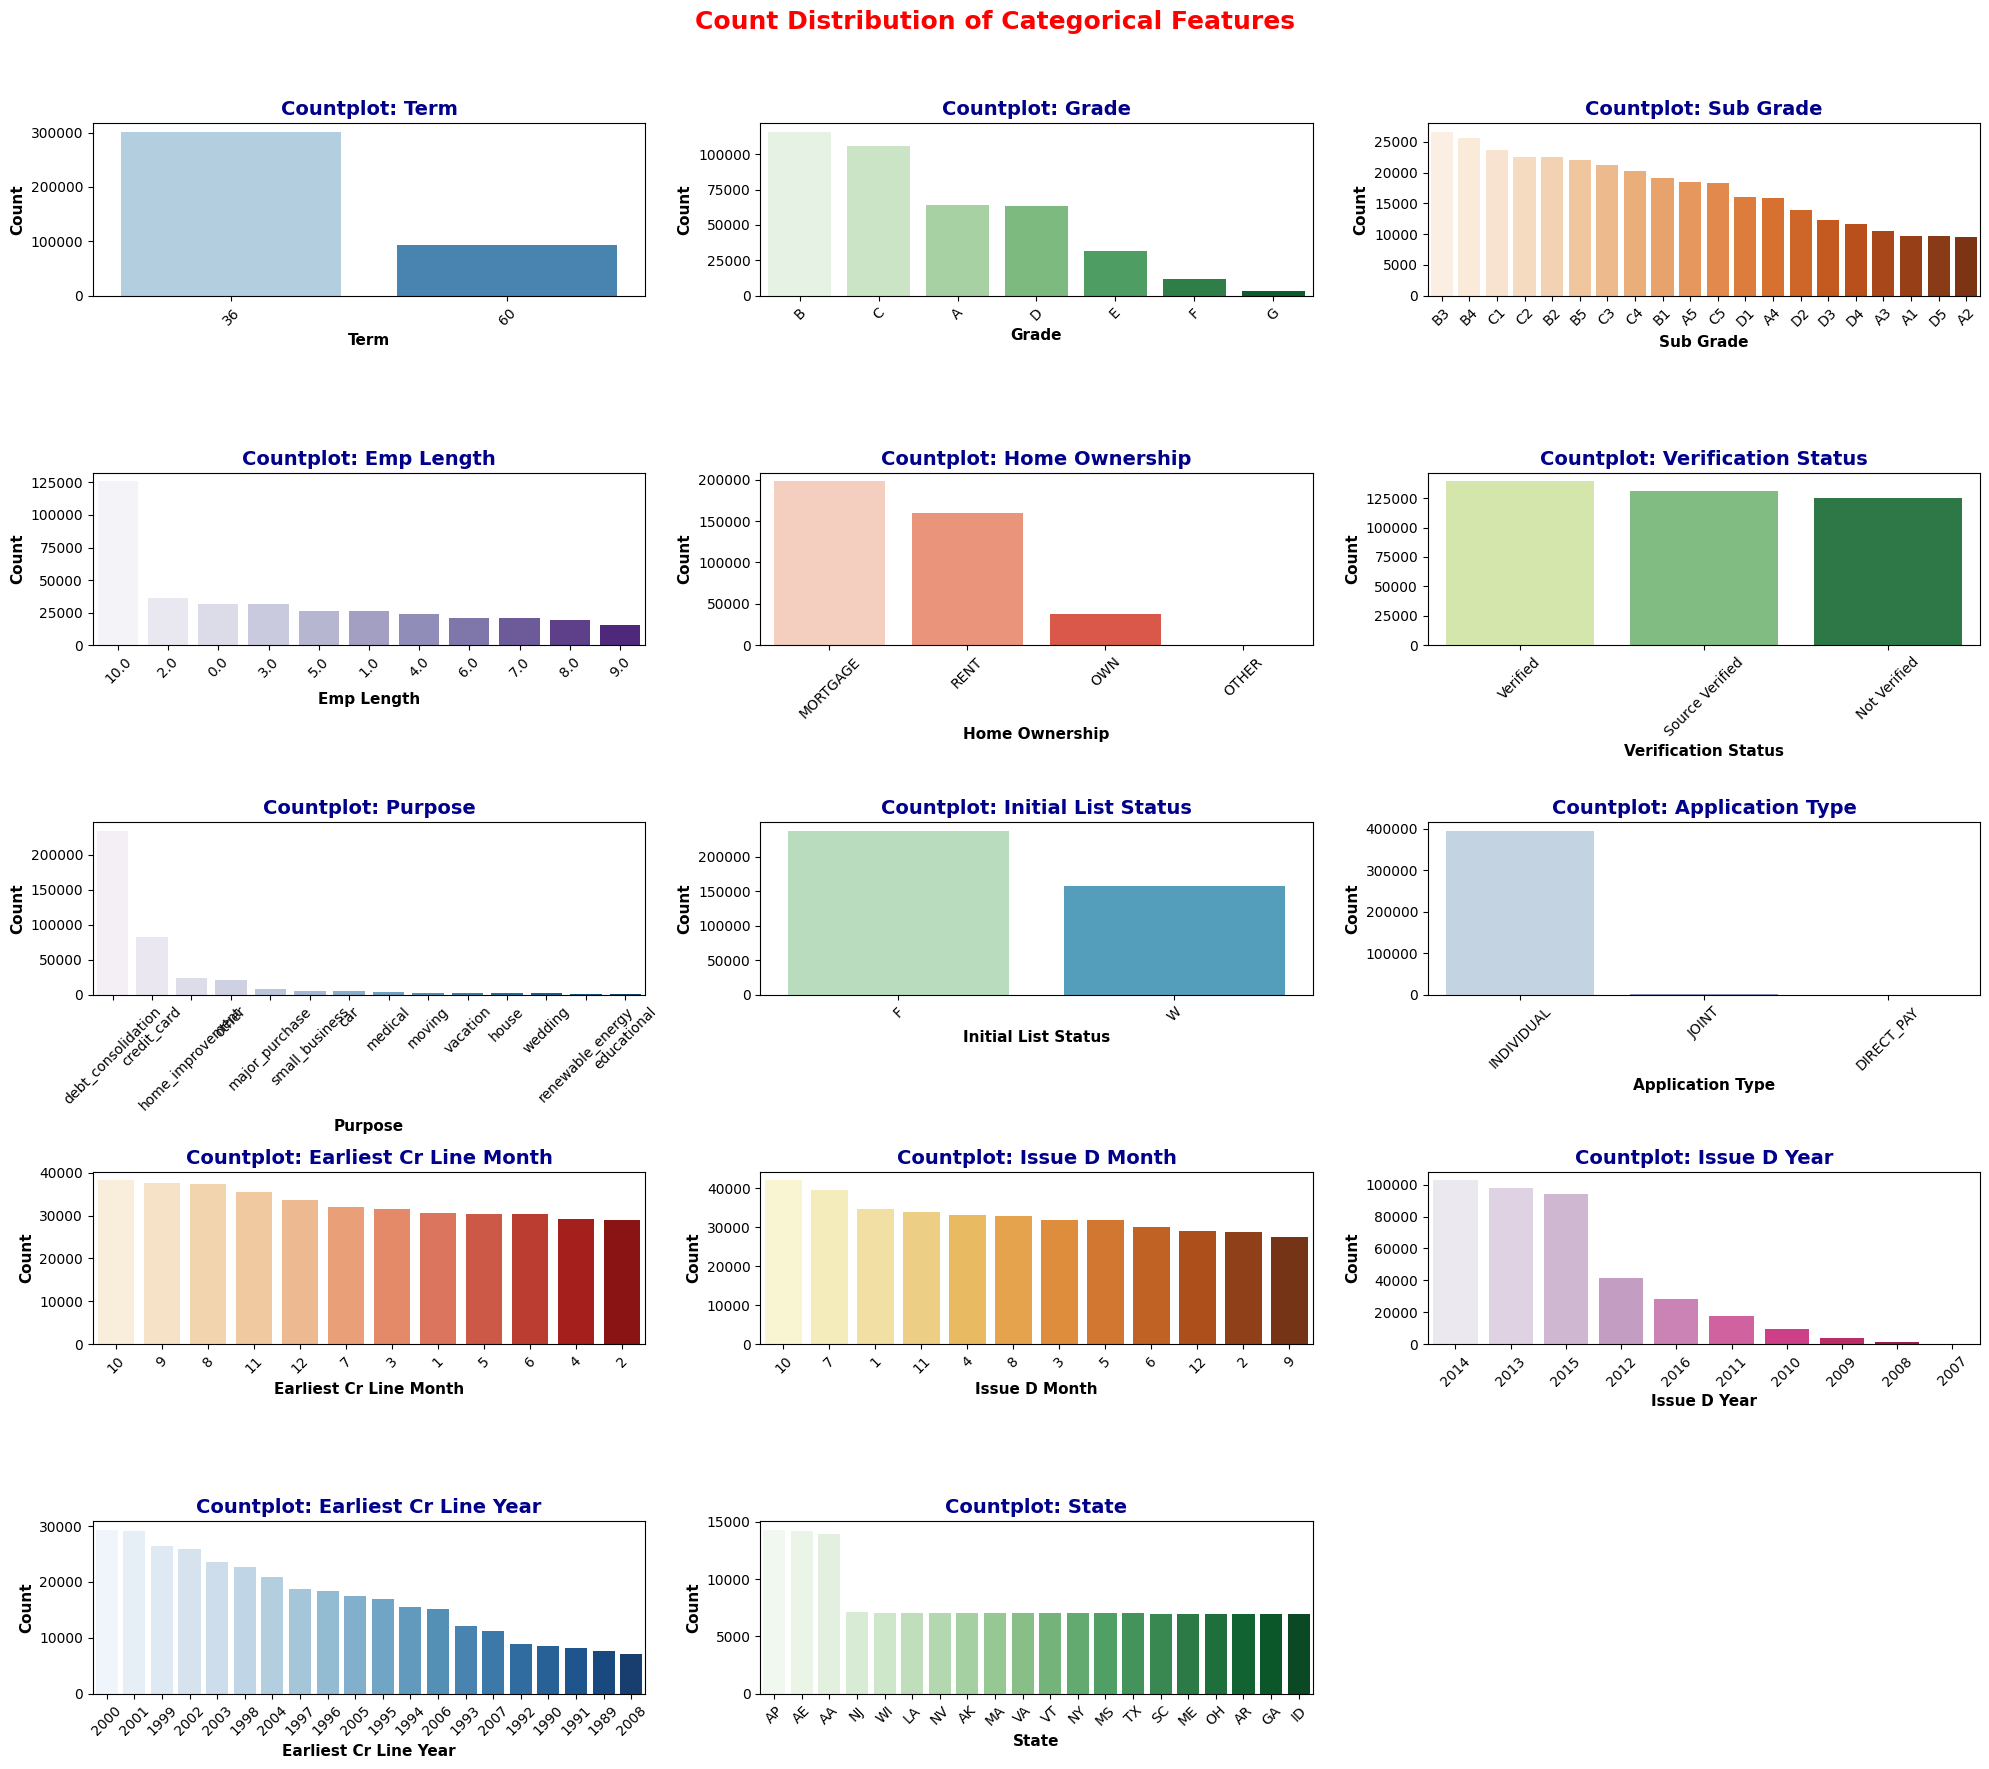

In [59]:
# Countplot of Categorical Features
features = ['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'initial_list_status',
            'application_type', 'earliest_cr_line_month', 'issue_d_month', 'issue_d_year', 'earliest_cr_line_year', 'state']

# Color palettes for each subplot
color_palettes = ['Blues', 'Greens', 'Oranges', 'Purples', 'Reds', 'YlGn', 'PuBu', 'GnBu', 'BuPu', 'OrRd', 'YlOrBr', 'PuRd', 'Blues', 'Greens']

# 5 rows × 3 columns grid
fig, axes = plt.subplots(5, 3, figsize = (20, 18))
axes = axes.flatten()

for ax, feature, palette in zip(axes, features, color_palettes):
    sns.countplot(data = df, x = feature, ax = ax, palette = palette, order = df[feature].value_counts().index[:20])  # top 20 categories only
    ax.set_title(f'Countplot: {feature.replace("_", " ").title()}', fontsize = 14, fontweight = 'bold', color = 'darkblue')
    ax.set_xlabel(feature.replace('_', ' ').title(), fontsize = 11, fontweight = 'bold')
    ax.set_ylabel('Count', fontsize = 11, fontweight = 'bold')
    ax.tick_params(axis = 'x', rotation = 45)

# Hide unused subplots if any
for ax in axes[len(features):]:
    ax.set_visible(False)

plt.suptitle('Count Distribution of Categorical Features', fontsize = 18, fontweight = 'bold', color = 'red')
plt.tight_layout(rect = [0, 0, 1, 0.96])
plt.show()

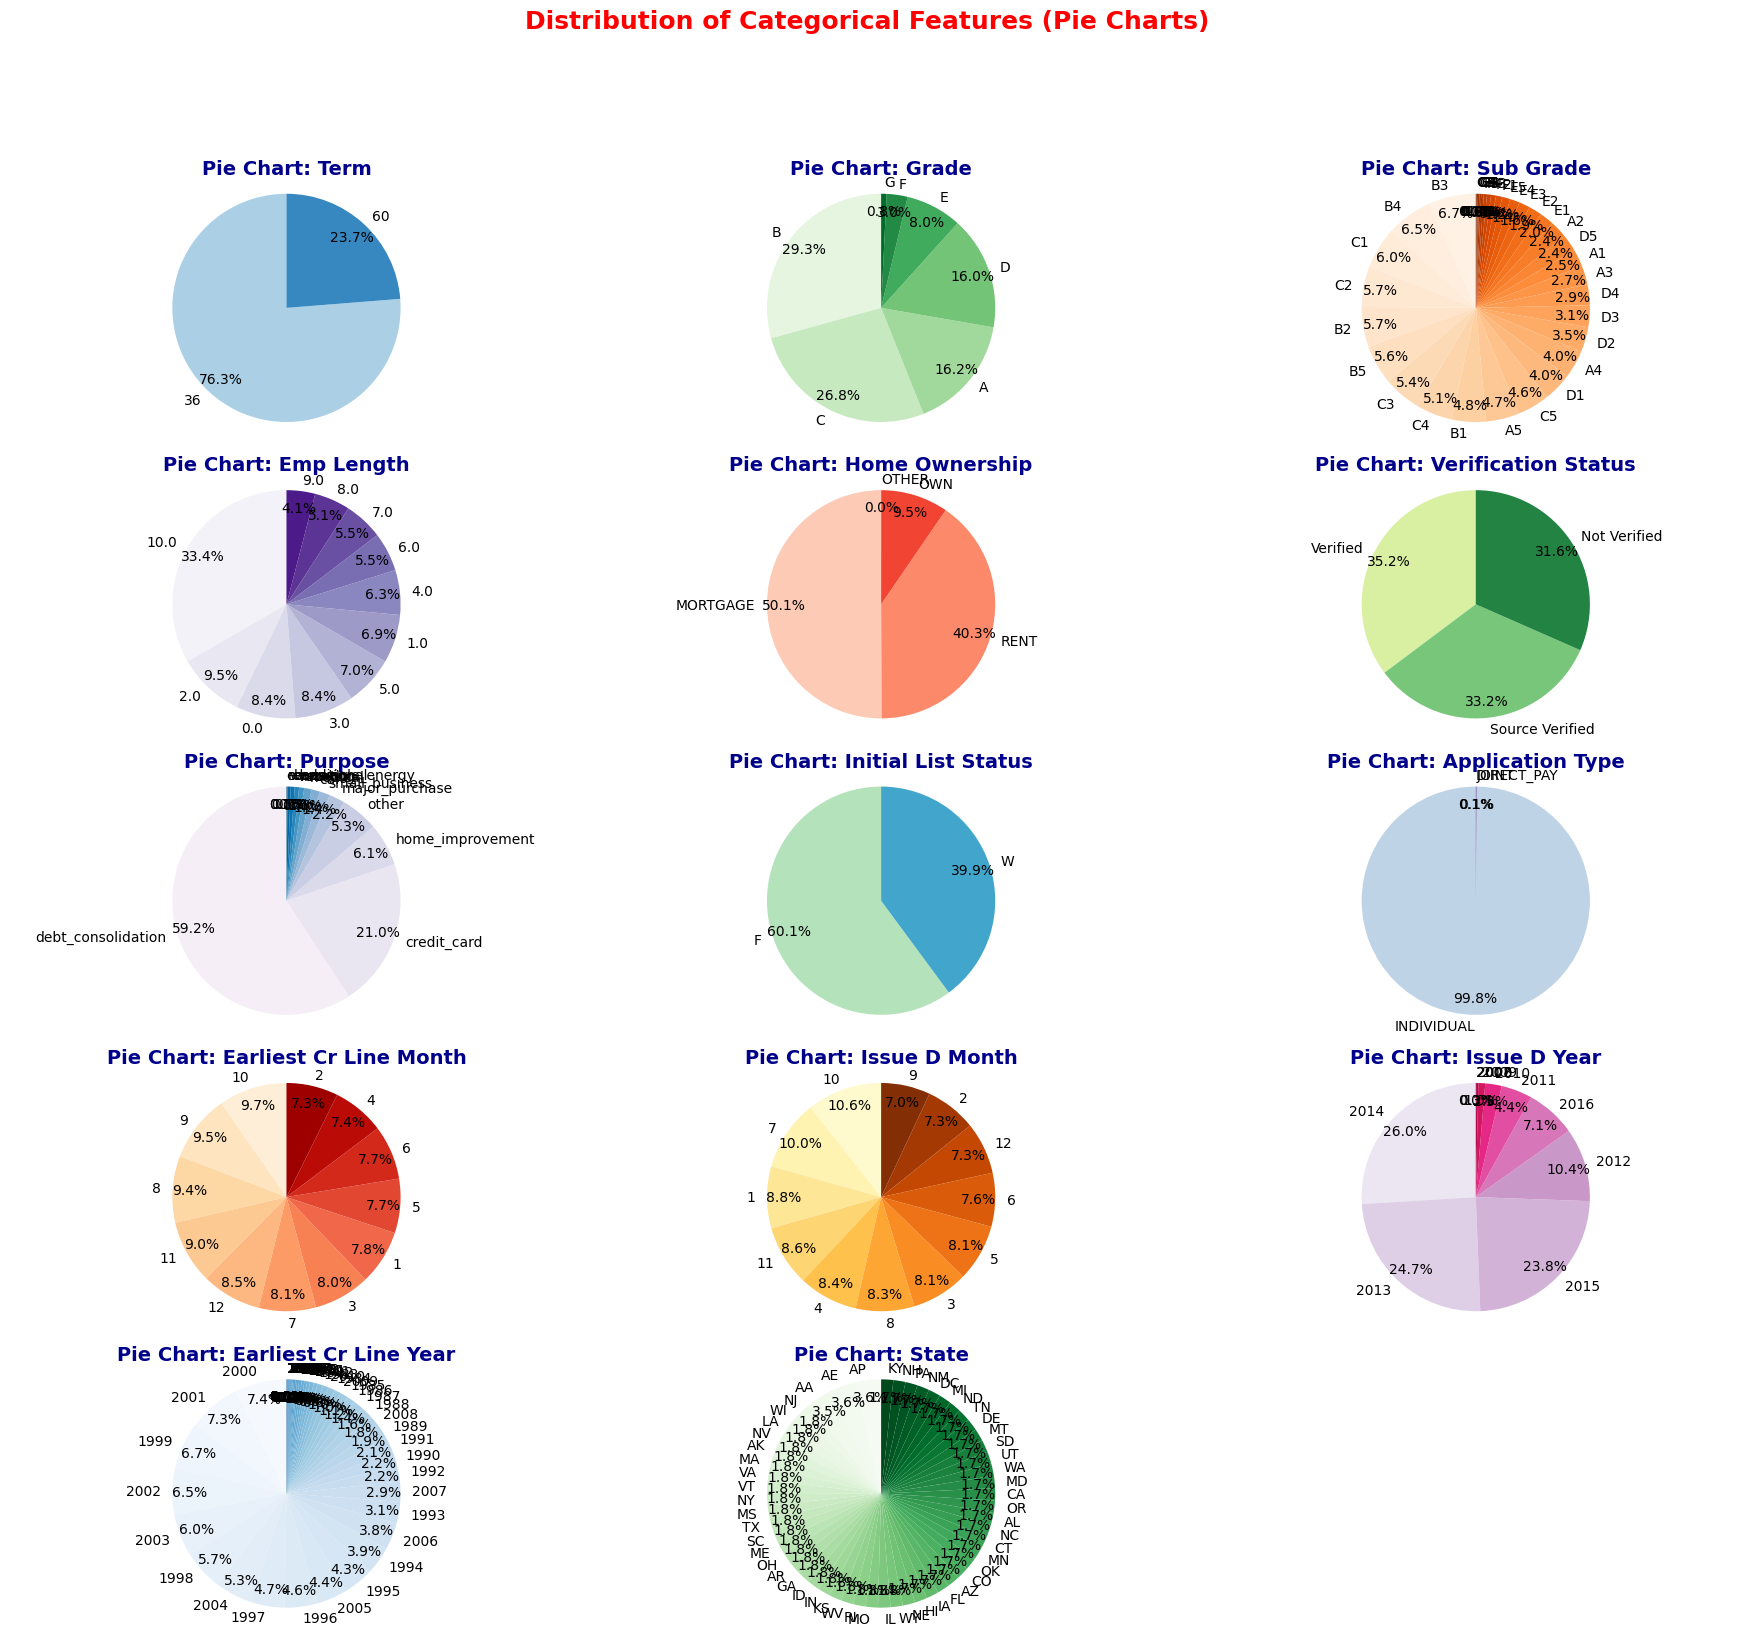

In [60]:
# Piechart of Categorical Features
features = ['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'initial_list_status',
            'application_type', 'earliest_cr_line_month', 'issue_d_month', 'issue_d_year', 'earliest_cr_line_year', 'state']

# Color palettes for each subplot
color_palettes = ['Blues', 'Greens', 'Oranges', 'Purples', 'Reds', 'YlGn', 'PuBu', 'GnBu', 'BuPu', 'OrRd', 'YlOrBr', 'PuRd', 'Blues', 'Greens']

# 5 rows × 3 columns grid
fig, axes = plt.subplots(5, 3, figsize = (18, 16))
axes = axes.flatten()

for ax, feature, palette in zip(axes, features, color_palettes):
    # Get value counts and labels
    value_counts = df[feature].value_counts()
    labels = value_counts.index
    sizes = value_counts.values

    # Choose colors from palette
    colors = sns.color_palette(palette, n_colors = len(labels))

    # Pie chart
    ax.pie(sizes, labels = labels, colors = colors, autopct = '%1.1f%%', startangle = 90, textprops = {'fontsize': 10}, pctdistance = 0.85)

    # Equal aspect ratio ensures pie is circular
    ax.axis('equal')
    ax.set_title(f'Pie Chart: {feature.replace("_", " ").title()}',
                 fontsize = 14, fontweight = 'bold', color = 'darkblue')

# Hide any unused subplots (if fewer than 12 features)
for ax in axes[len(features):]:
    ax.set_visible(False)

plt.suptitle('Distribution of Categorical Features (Pie Charts)', fontsize = 18, fontweight = 'bold', color = 'red', y = 1.02)
plt.tight_layout(rect = [0, 0, 1, 0.96])
plt.show()

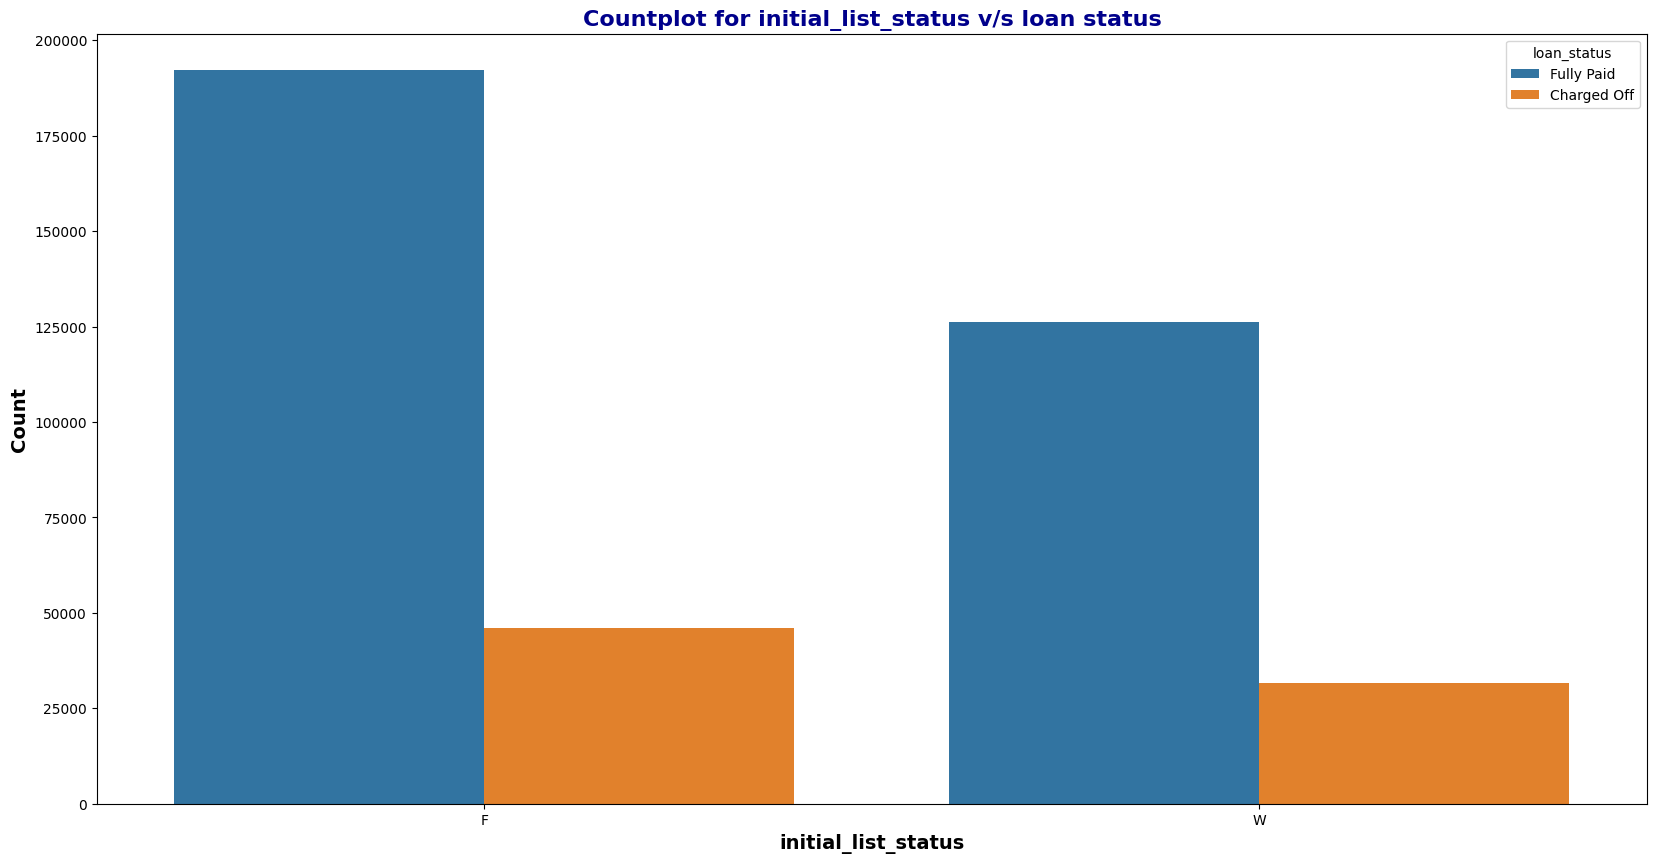

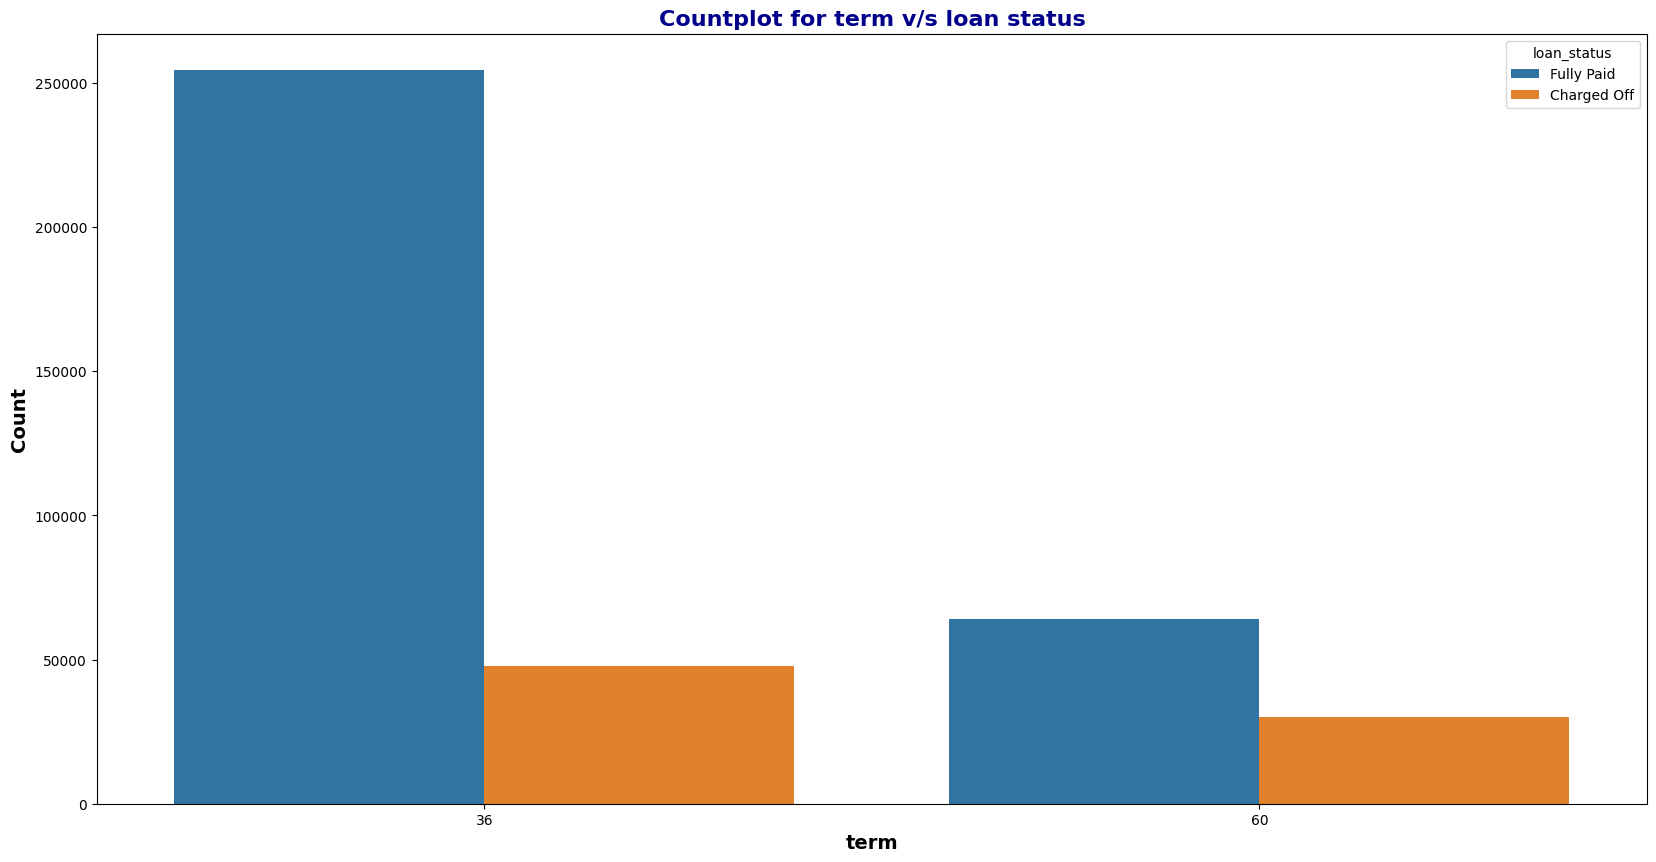

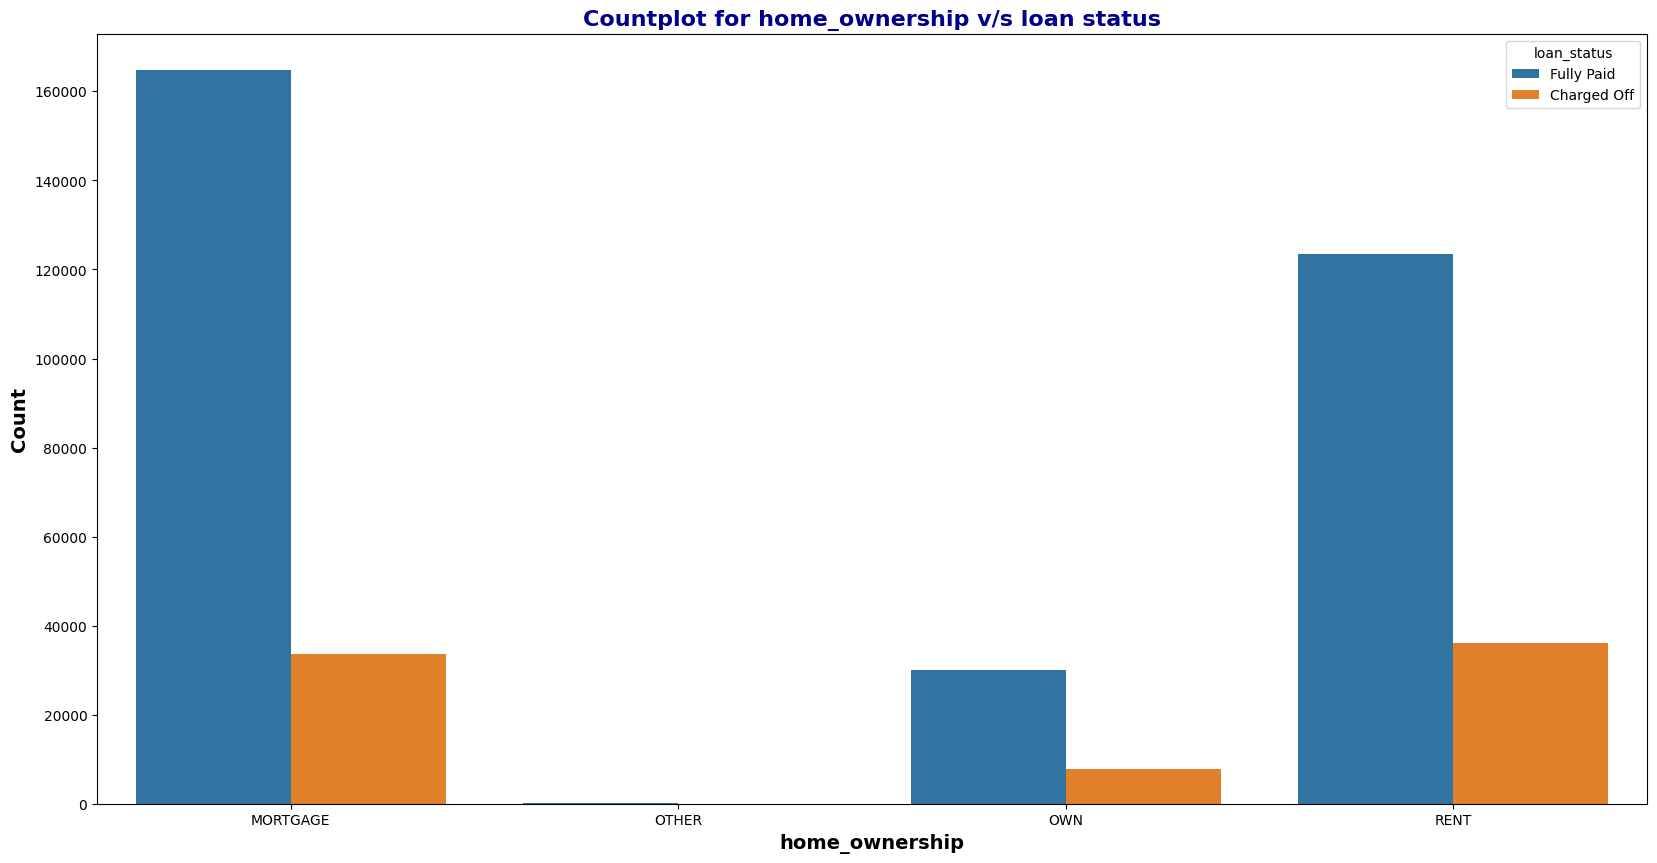

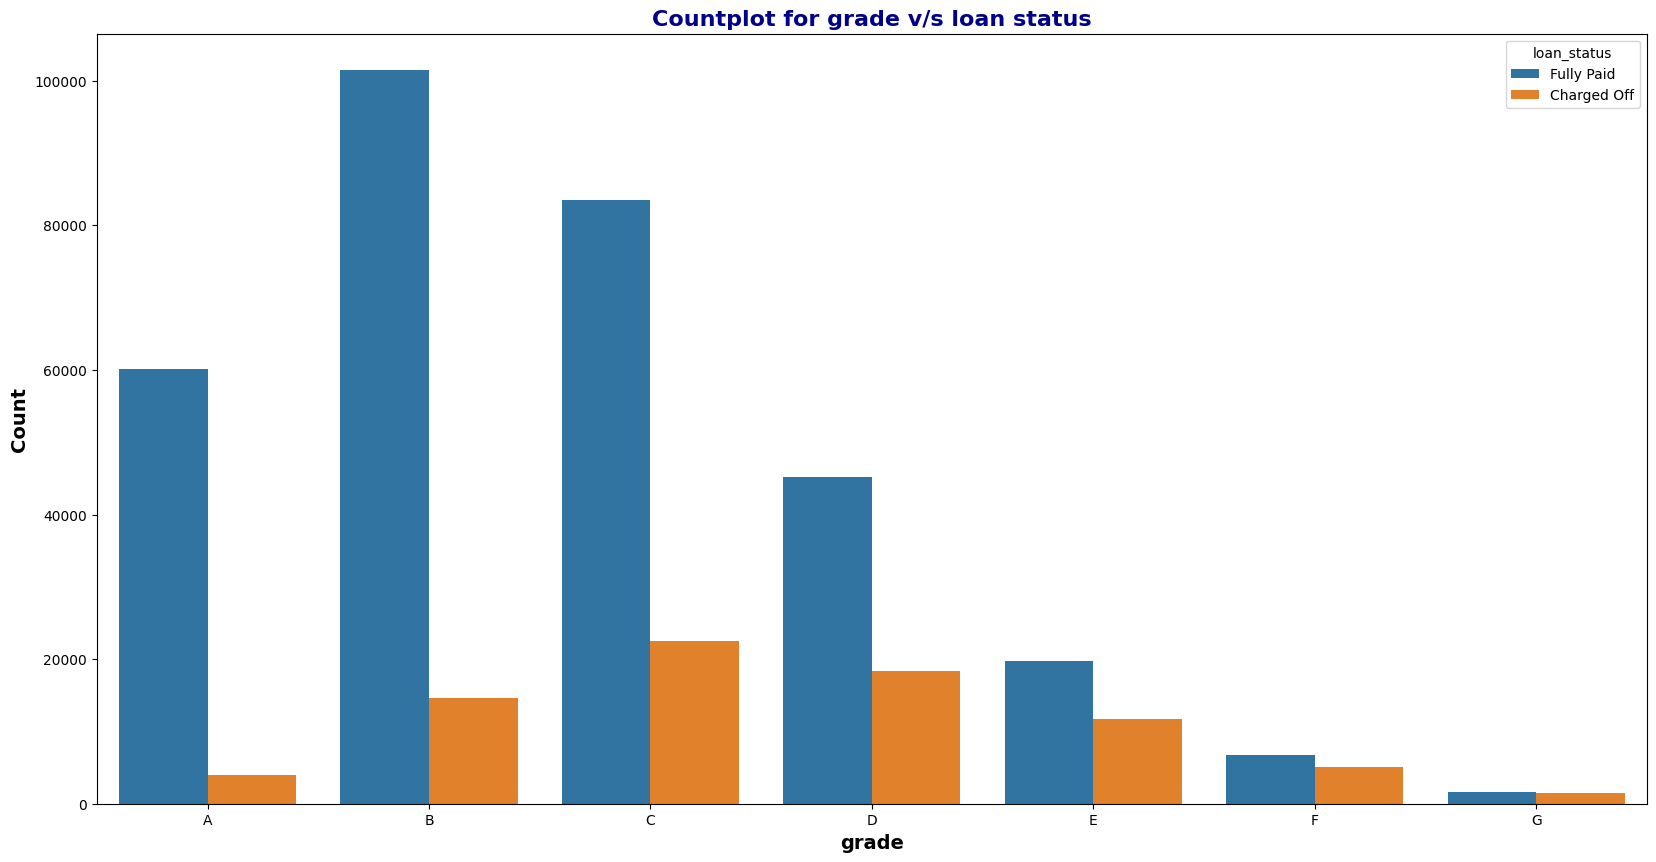

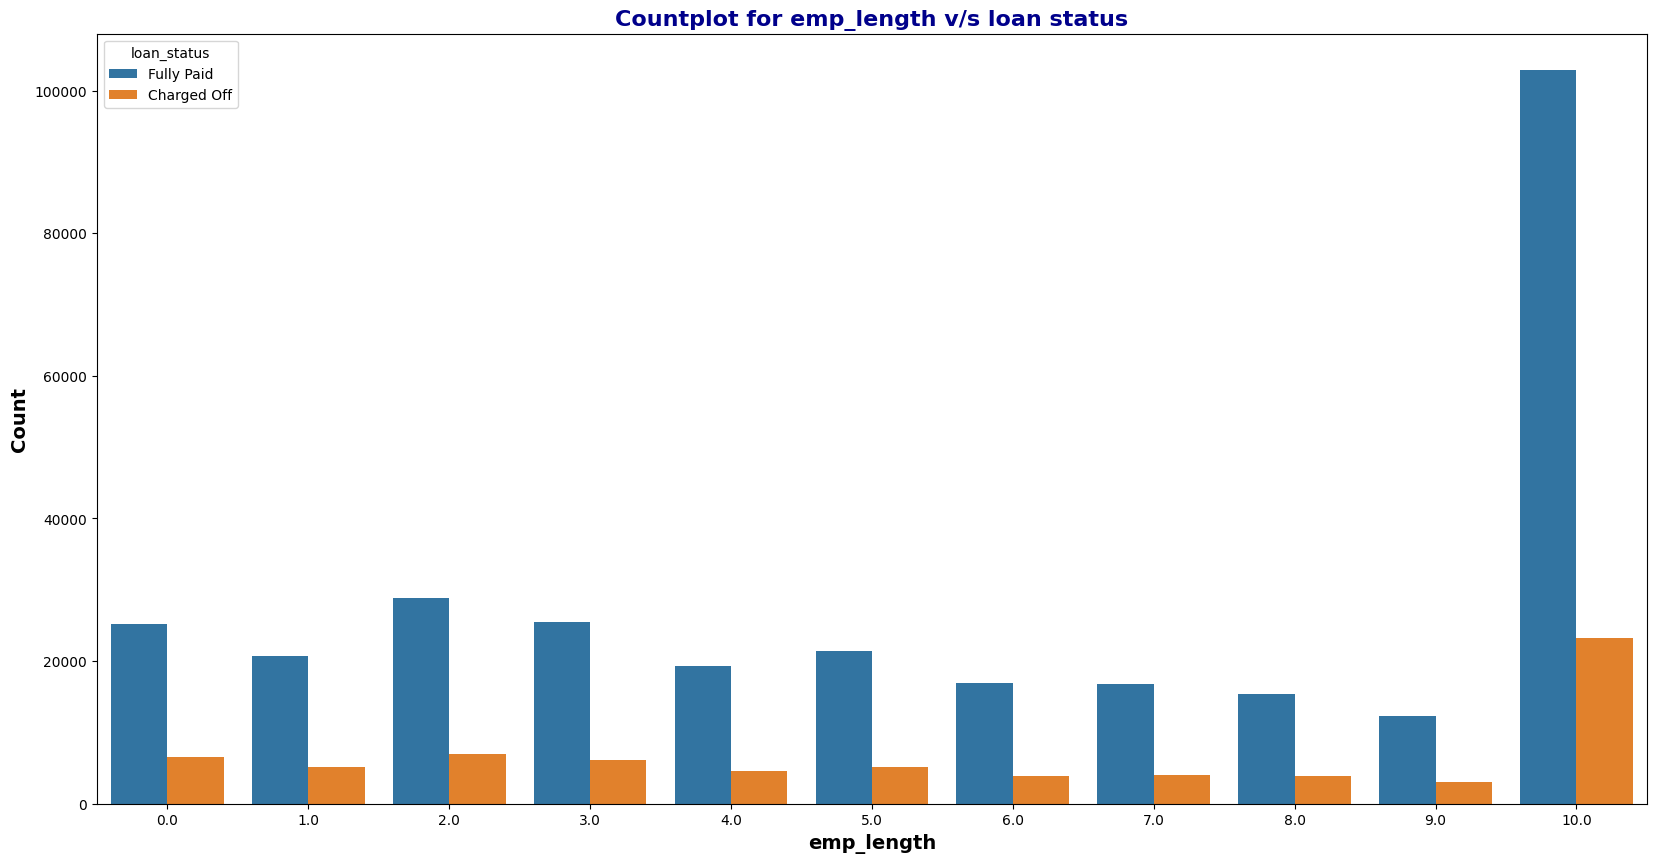

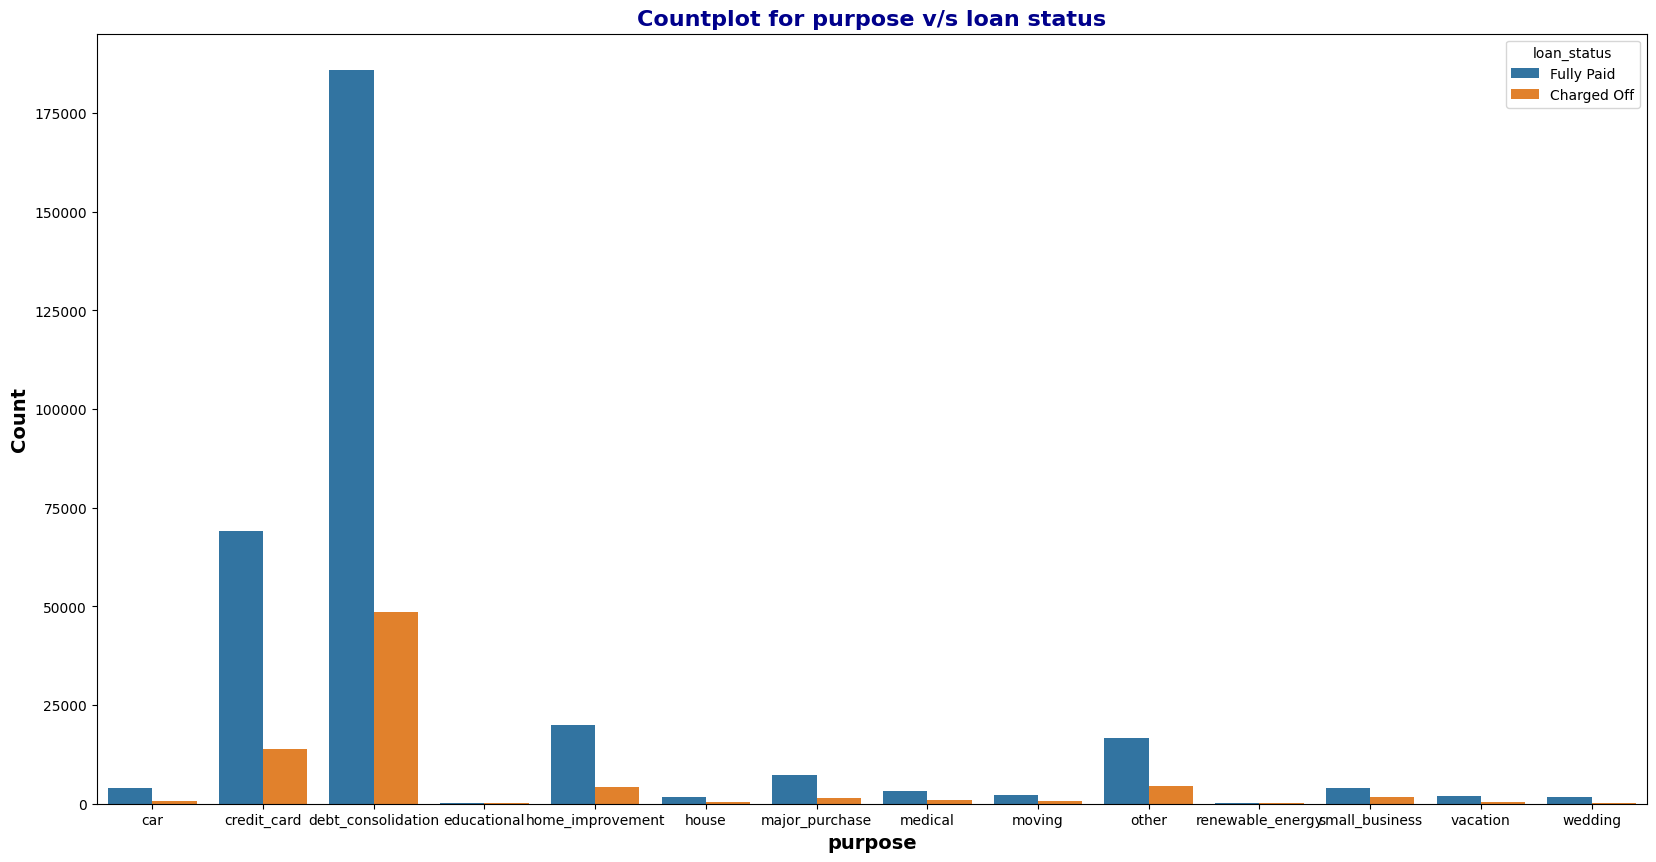

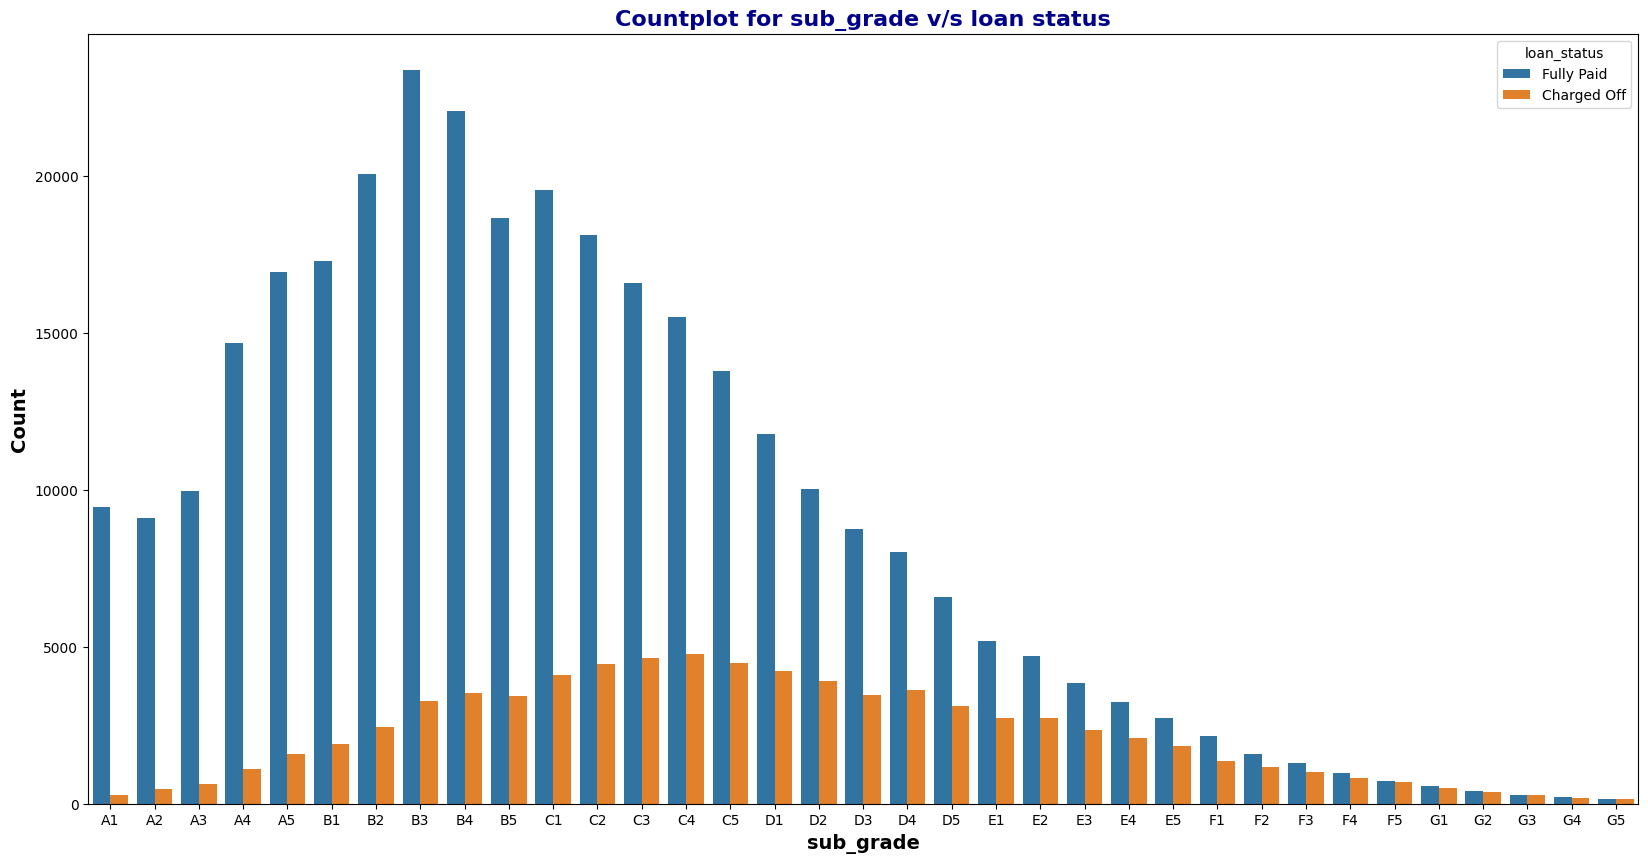

In [61]:
# Bivariate Analysis - Countplot for features vs loan status
features = ['initial_list_status', 'term', 'home_ownership', 'grade', 'emp_length', 'purpose', 'sub_grade']

for col in features:
    plt.figure(figsize = (20,10))
    sns.countplot(data = df, x = col, hue = 'loan_status')
    plt.title(f'Countplot for {col} v/s loan status', fontsize = 16, fontweight = 'bold', color = 'darkblue')
    plt.xlabel(col, fontsize = 14, fontweight = 'bold')
    plt.ylabel('Count', fontsize = 14, fontweight = 'bold')
    plt.show()

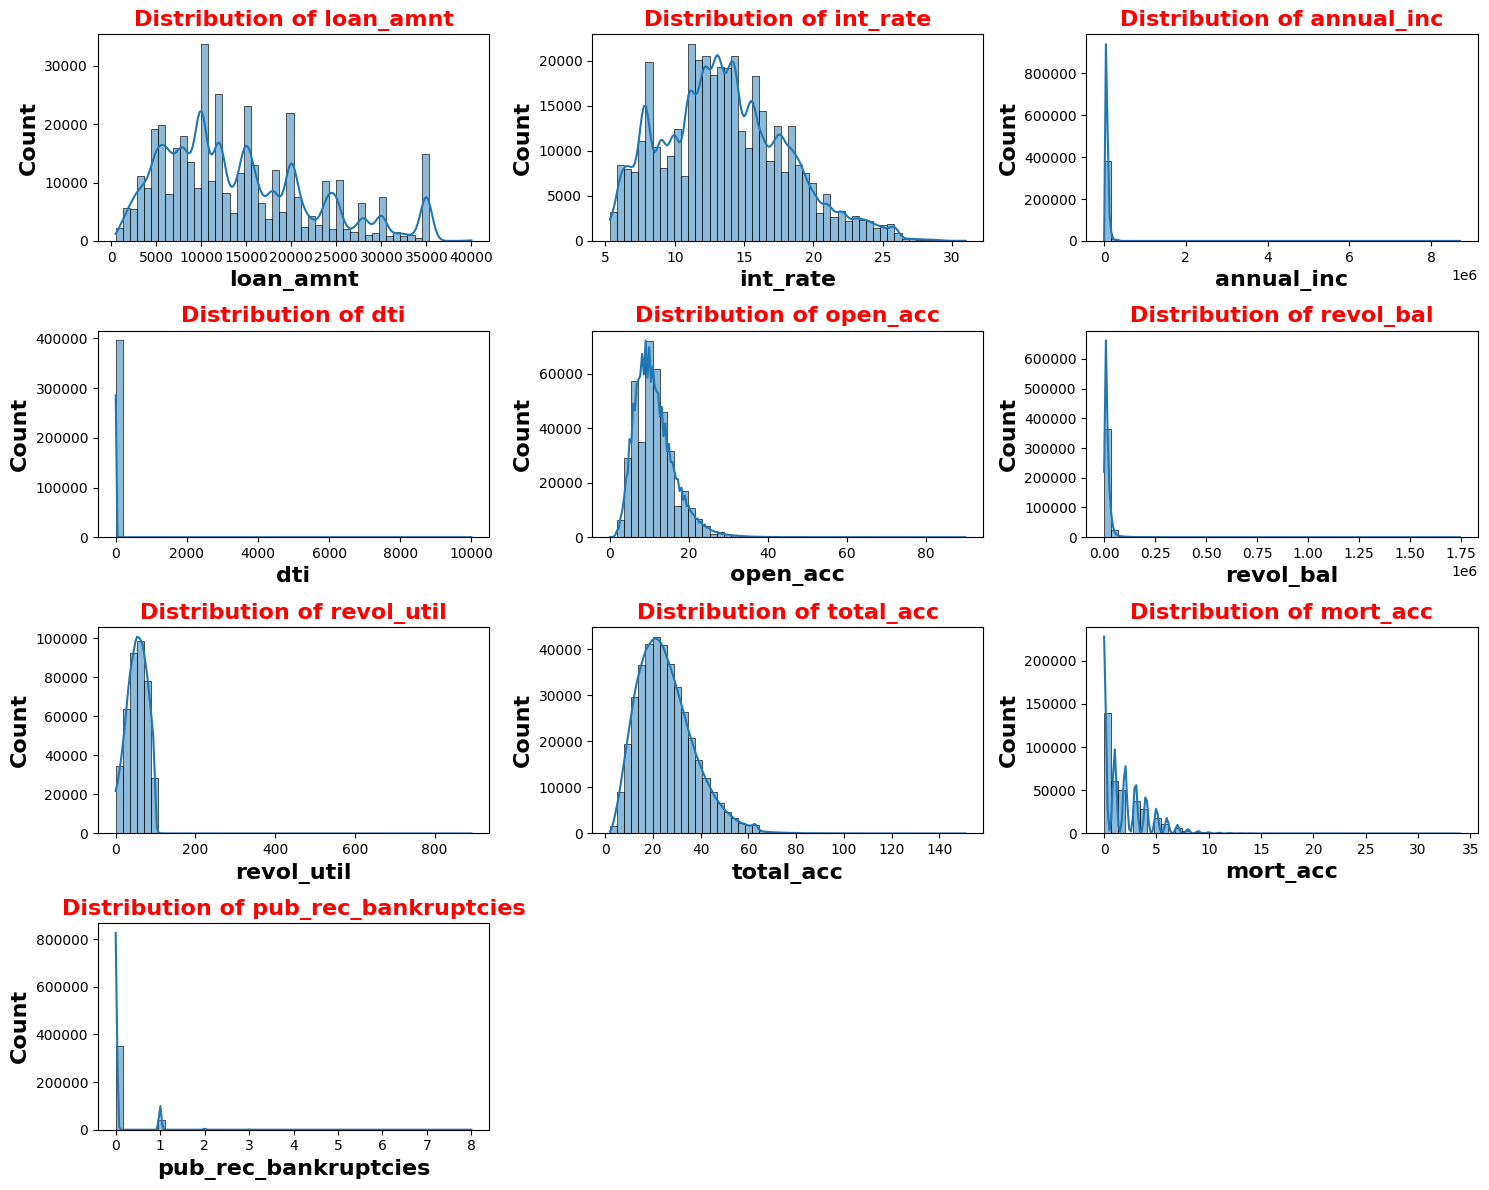

In [62]:
# Histplot for numerical features
features = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'open_acc', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies']

plt.figure(figsize = (15, 12))
for i, col in enumerate(features, 1):
    plt.subplot(4, 3, i)
    sns.histplot(data = df, x = col, kde = True, bins = 50)
    plt.title(f'Distribution of {col}', fontsize = 16, fontweight = 'bold', color = 'red')
    plt.xlabel(col, fontsize = 16, fontweight = 'bold')
    plt.ylabel('Count', fontsize = 16, fontweight = 'bold')
plt.tight_layout()
plt.show()

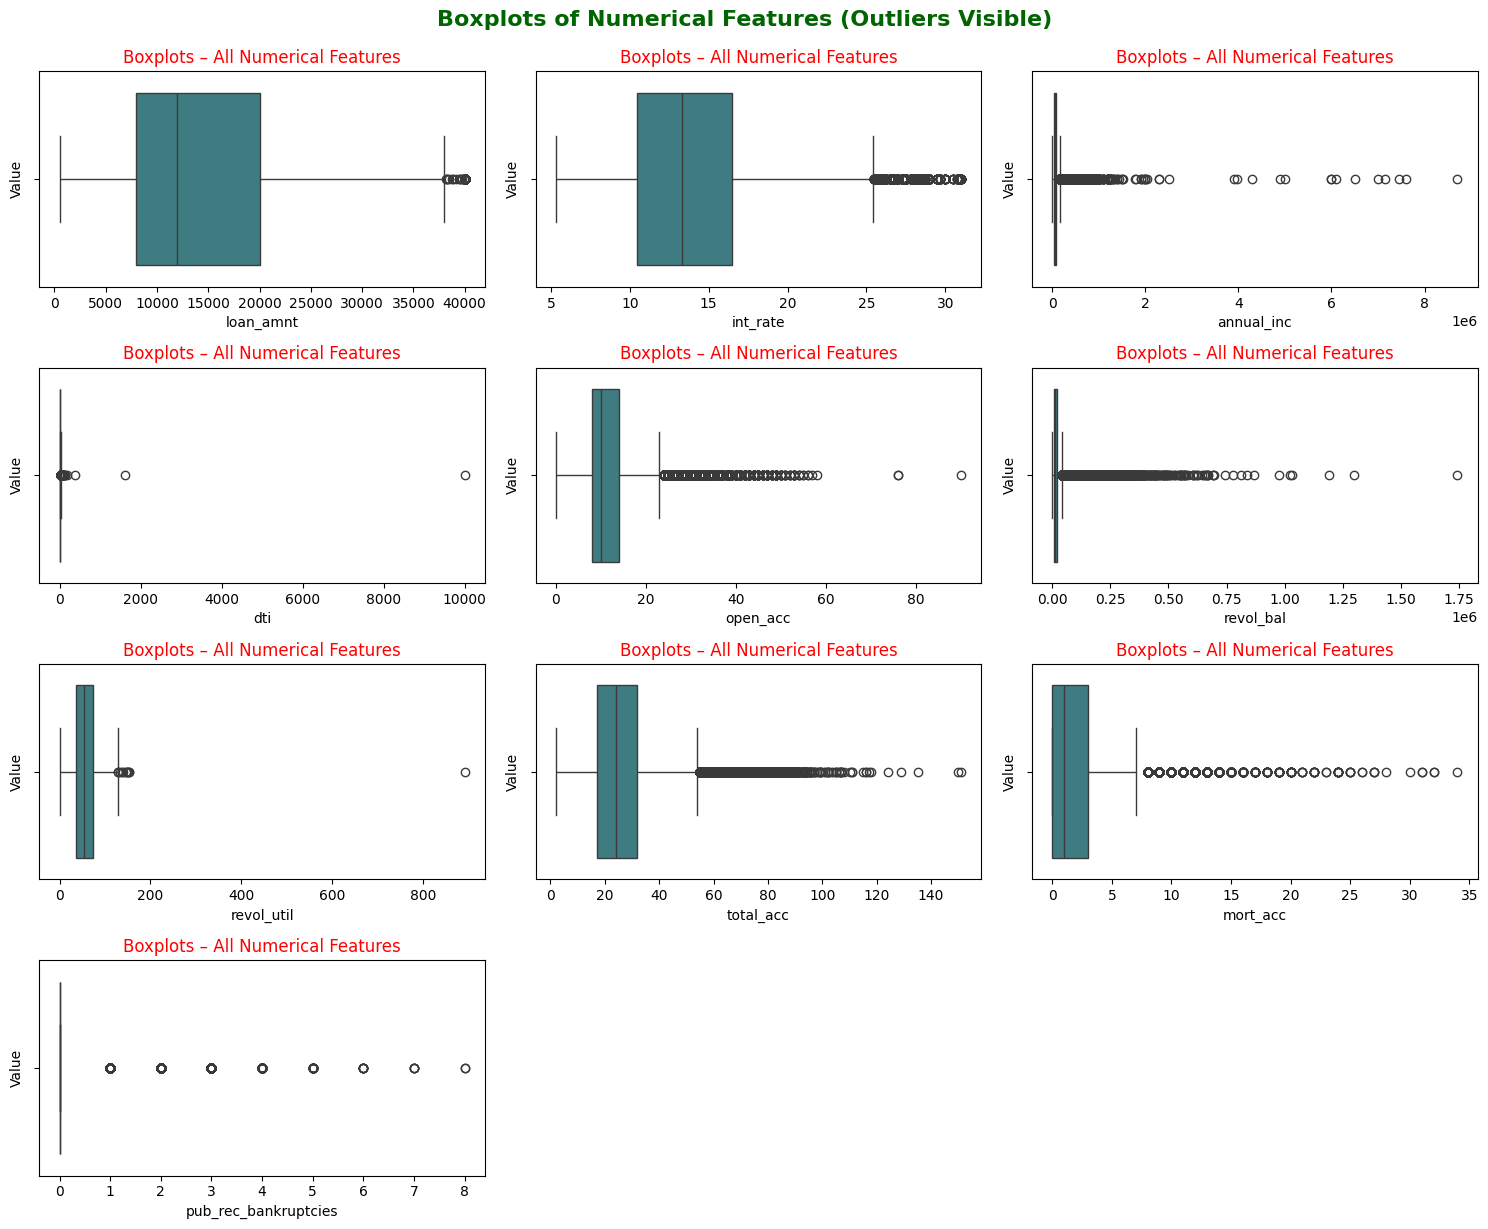

In [63]:
# Boxplot for numerical features
features = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'open_acc', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies']

plt.figure(figsize = (15, 12))
for i, col in enumerate(features, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(data = df, x = col, orient = 'h', palette = 'crest')
    plt.title(f'Boxplot of {col}', fontsize = 16, fontweight = 'bold', color = 'red')
    plt.title('Boxplots – All Numerical Features')
    plt.xlabel(col)
    plt.ylabel('Value')
plt.tight_layout()
plt.suptitle('Boxplots of Numerical Features (Outliers Visible)', fontsize = 16, fontweight = 'bold', color = 'darkgreen', y = 1.02)
plt.show()

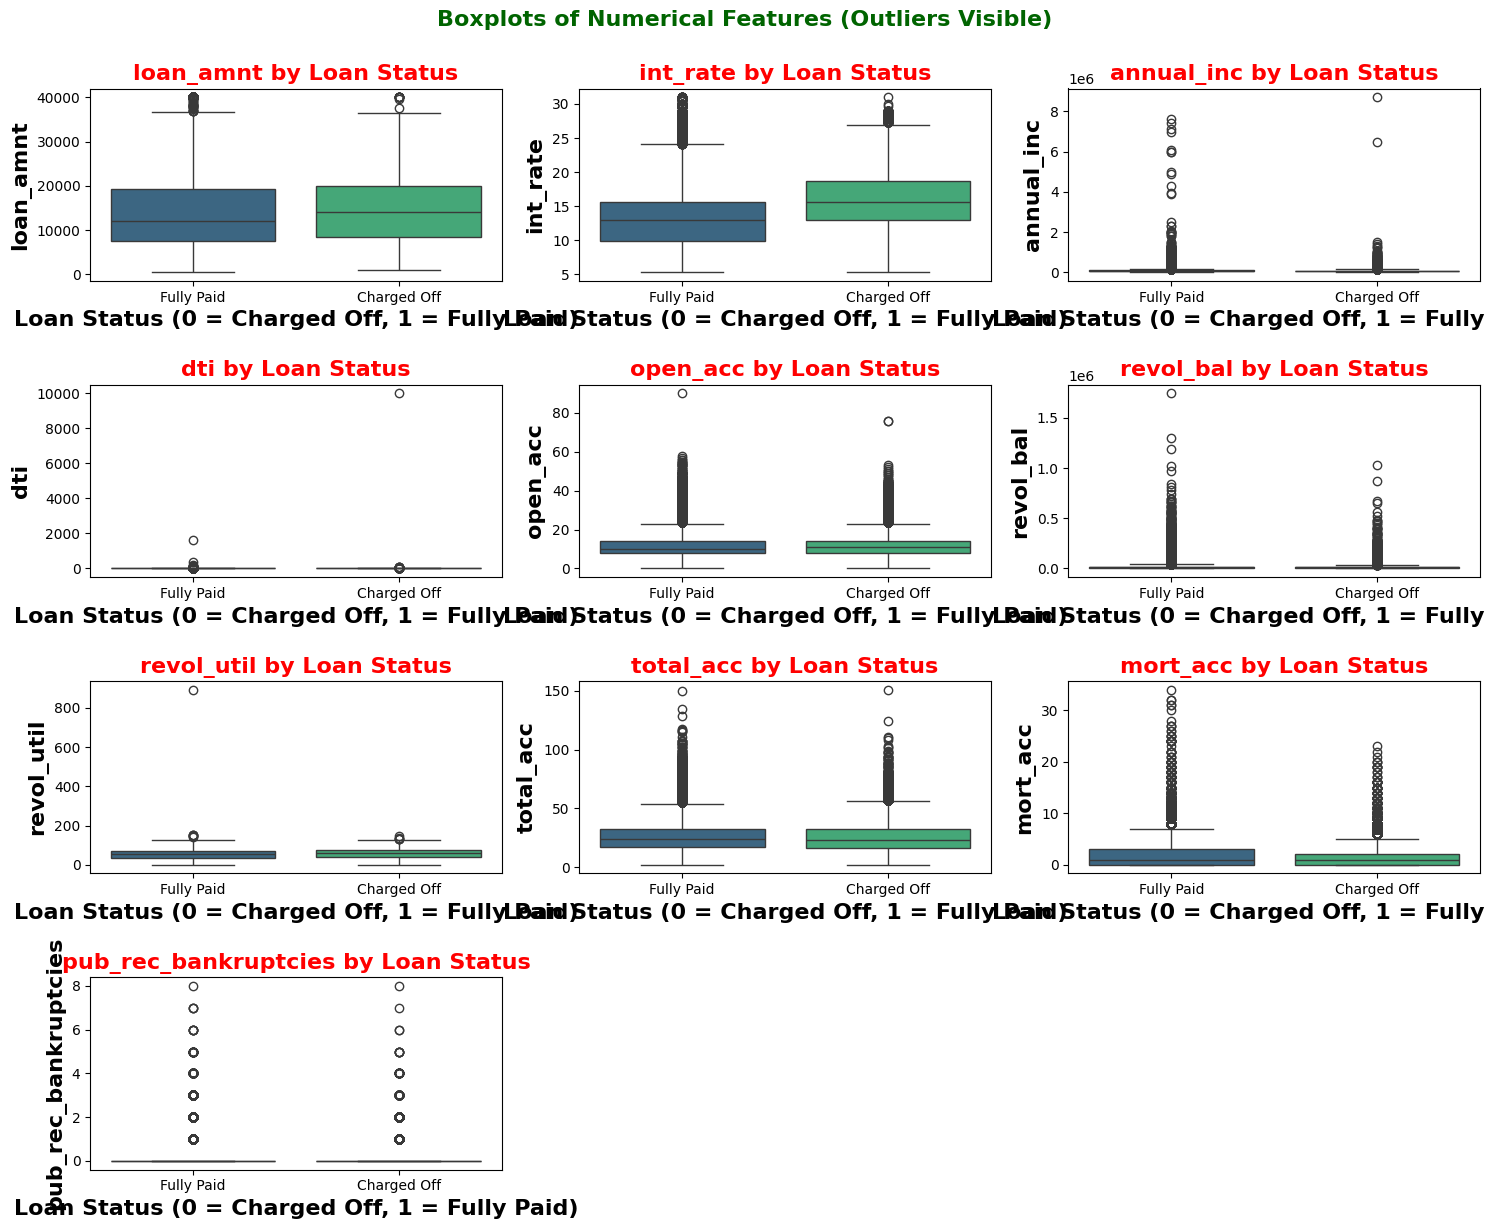

In [64]:
# Boxplots for numerical features v/s loan status
features = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'open_acc', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies']

plt.figure(figsize = (15, 12))
for i, col in enumerate(features, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(data = df, x = 'loan_status', y = col, palette = 'viridis')
    plt.title(f'{col} by Loan Status', fontsize = 16, fontweight = 'bold', color = 'red')
    plt.xlabel('Loan Status (0 = Charged Off, 1 = Fully Paid)', fontsize = 16, fontweight = 'bold')
    plt.ylabel(col, fontsize = 16, fontweight = 'bold')
plt.tight_layout()
plt.suptitle('Boxplots of Numerical Features (Outliers Visible)', fontsize = 16, fontweight = 'bold', color = 'darkgreen', y = 1.02)
plt.show()

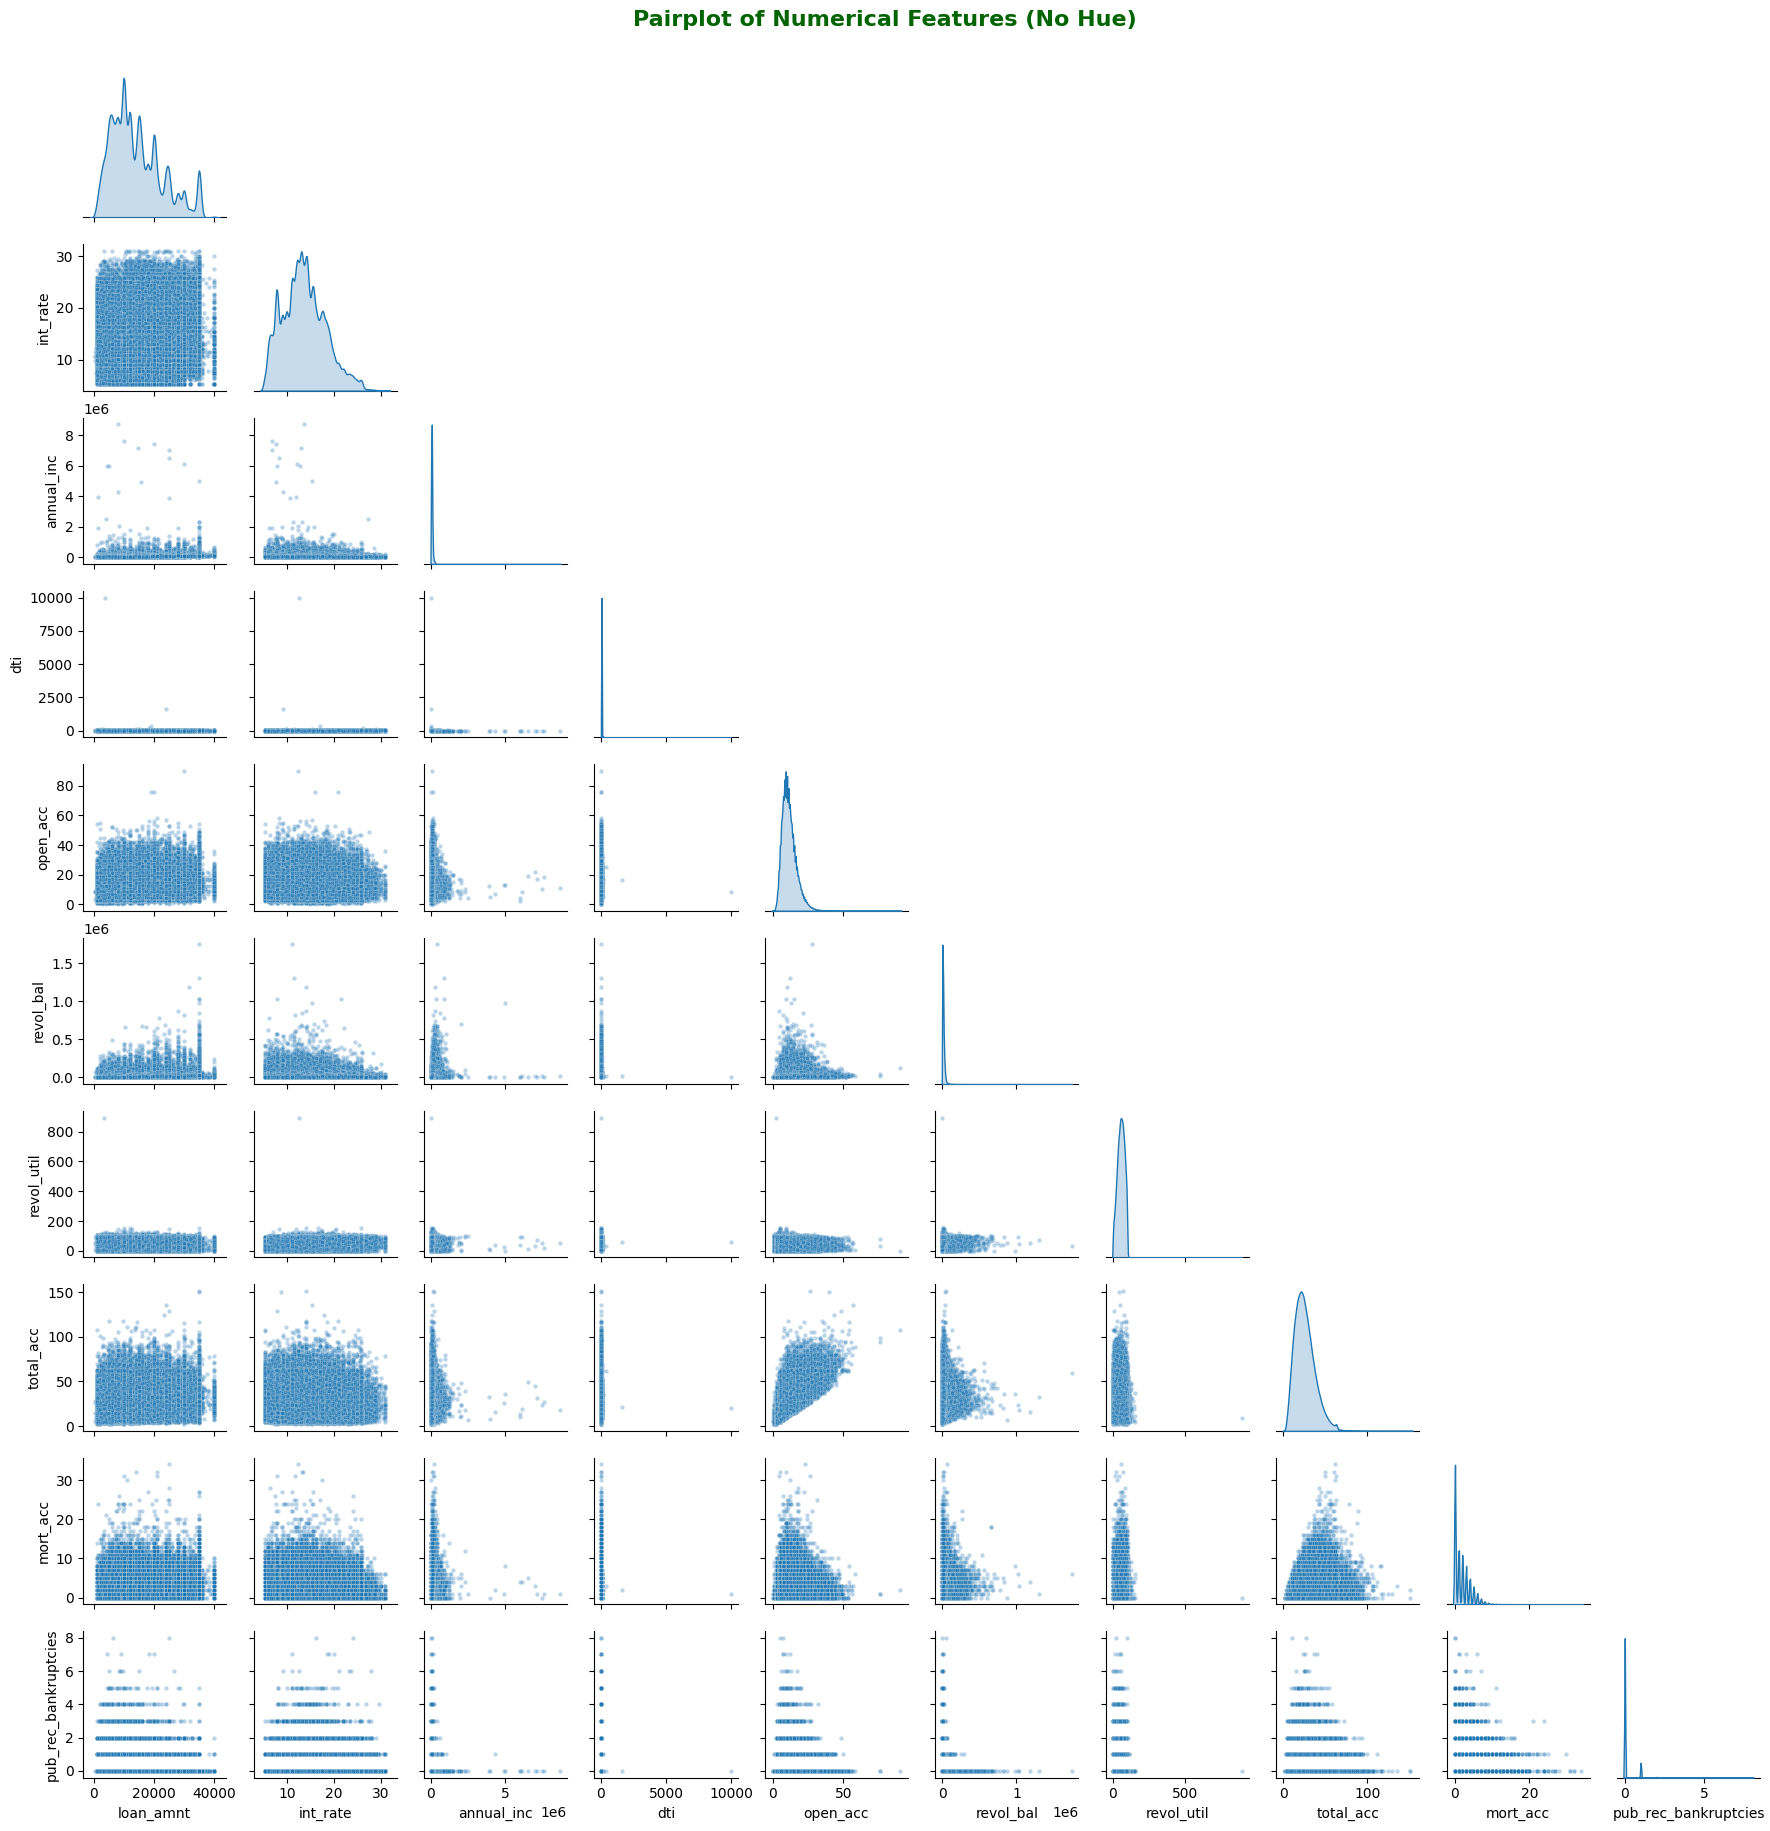

In [65]:
features = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'open_acc', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies']

# Pairplot – no hue, only numeric features
sns.pairplot(data = df[features], diag_kind = 'kde', corner = True, plot_kws = {'alpha': 0.3, 's': 10}, height = 1.8)
plt.suptitle('Pairplot of Numerical Features (No Hue)', fontsize = 16, fontweight = 'bold', color = 'darkgreen', y = 1.02)
plt.show()

# **Part F: Logistic Regression Models**

In [66]:
# Encode target: Convert loan_status into binary 0/1
encode_target = {'Charged Off' : 1, 'Fully Paid' : 0}
df['loan_status'] = df['loan_status'].map(encode_target)

## **A. Import the required libraries**

In [67]:
# Import the required libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, auc
from sklearn.metrics import roc_curve, precision_recall_curve

## **B. Train Test Split**

In [68]:
# Train Test Split
X = df.drop('loan_status', axis = 1)
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)
print("Shape of X_train: ", X_train.shape)
print("Shape of X_test: ", X_test.shape)
print("Shape of y_train: ", y_train.shape)
print("Shape of y_test: ", y_test.shape)

Shape of X_train:  (316824, 24)
Shape of X_test:  (79206, 24)
Shape of y_train:  (316824,)
Shape of y_test:  (79206,)


## **C. Missing Values treatment**

In [69]:
# Check for missing values and their percentage
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Combine into a dataFrame for better readability
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_percentage})
missing_df

,Missing Values,Percentage (%)
loan_amnt,0,0.000000
term,0,0.000000
int_rate,0,0.000000
grade,0,0.000000
sub_grade,0,0.000000
emp_length,18301,4.621115
home_ownership,0,0.000000
annual_inc,0,0.000000
verification_status,0,0.000000
loan_status,0,0.000000


- mort_acc ~ 9.54% missing (highest)

- emp_length ~ 4.62% missing

- pub_rec_bankruptcies ~ 0.135% missing

- revol_util ~ 0.07% missing

- Other features have 0% data missing

In [70]:
df[['mort_acc', 'emp_length', 'pub_rec_bankruptcies', 'revol_util']].dtypes

,0
mort_acc,float64
emp_length,float64
pub_rec_bankruptcies,float64
revol_util,float64


In [71]:
# Impute missing values
X_train['revol_util'] = X_train['revol_util'].fillna(X_train['revol_util'].median())
X_test['revol_util'] = X_test['revol_util'].fillna(X_train['revol_util'].median())

X_train['mort_acc'] = X_train['mort_acc'].fillna(0)
X_test['mort_acc'] = X_test['mort_acc'].fillna(0)

X_train['pub_rec_bankruptcies'] = X_train['pub_rec_bankruptcies'].fillna(0)
X_test['pub_rec_bankruptcies'] = X_test['pub_rec_bankruptcies'].fillna(0)

X_train['emp_length'] = X_train['emp_length'].fillna(X_train['emp_length'].median())
X_test['emp_length'] = X_test['emp_length'].fillna(X_train['emp_length'].median())

In [72]:
print("Any missing values left in train?", X_train.isnull().any().any())
print("Any missing values left in test? ", X_test.isnull().any().any())

Any missing values left in train? False
Any missing values left in test?  False


## **The dataset is clean with no duplicates and no missing values.**

## **D: Outlier Treatment**

In [73]:
X_train.dtypes

,0
loan_amnt,float64
term,int64
int_rate,float64
grade,category
sub_grade,category
emp_length,float64
home_ownership,category
annual_inc,float64
verification_status,category
purpose,category


In [74]:
X_test.dtypes

,0
loan_amnt,float64
term,int64
int_rate,float64
grade,category
sub_grade,category
emp_length,float64
home_ownership,category
annual_inc,float64
verification_status,category
purpose,category


In [75]:
numeric_cols = X_train.select_dtypes(include=['float64', 'int64']).columns

Q1 = X_train[numeric_cols].quantile(0.25)
Q3 = X_train[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

X_train[numeric_cols] = X_train[numeric_cols].clip(lower = lower_bound, upper = upper_bound, axis = 1)
X_test[numeric_cols]  = X_test[numeric_cols].clip(lower = lower_bound, upper = upper_bound, axis = 1)

In [76]:
print("Shape of X_train after outlier treatment: ", X_train.shape)
print("Shape of X_test after outlier treatment: ", X_test.shape)
print("Shape of y_train after outlier treatment: ", y_train.shape)
print("Shape of y_test after outlier treatment: ", y_test.shape)

Shape of X_train after outlier treatment:  (316824, 24)
Shape of X_test after outlier treatment:  (79206, 24)
Shape of y_train after outlier treatment:  (316824,)
Shape of y_test after outlier treatment:  (79206,)


## **E: Simple Feature Engineering steps (Creation of Flags)**

In [77]:
# If value greater than 1.0 then 1 else 0
X_train['mort_acc_flag'] = (X_train['mort_acc'] > 0).astype('int8')
X_train['pub_rec_bankruptcies_flag'] = (X_train['pub_rec_bankruptcies'] > 0).astype('int8')

X_test['mort_acc_flag'] = (X_test['mort_acc'] > 0).astype('int8')
X_test['pub_rec_bankruptcies_flag'] = (X_test['pub_rec_bankruptcies'] > 0).astype('int8')

## **F: Encoding Categorical Features**

In [78]:
# Encoding categorical features
# One-hot encoding (drop_first to avoid multicollinearity)

categorical_cols = X_train.select_dtypes(include = ['object','category']).columns

X_train = pd.get_dummies(X_train, columns = categorical_cols, drop_first = True, dtype = 'int8')
X_test  = pd.get_dummies(X_test,  columns = categorical_cols, drop_first = True, dtype = 'int8')

# Align columns (in case some categories missing in test)
# X_test = X_test.reindex(columns = X_train.columns, fill_value = 0)

print("\nShape after encoding => Train:", X_train.shape, "Test:", X_test.shape)


Shape after encoding => Train: (316824, 152) Test: (79206, 152)


In [79]:
# After get_dummies
if set(X_train.columns) != set(X_test.columns):
    print("Column mismatch detected! Aligning columns...")
    X_test = X_test.reindex(columns = X_train.columns, fill_value = 0)
else:
    print("Columns are already aligned")

Columns are already aligned


## **G: Scaling Numerical Features**

In [80]:
# Scaling Numerical Features
scaler = StandardScaler()

# Select numeric columns after encoding
num_cols_after_encoding = X_train.select_dtypes(include = ['float64','int64']).columns

X_train[num_cols_after_encoding] = scaler.fit_transform(X_train[num_cols_after_encoding])
X_test[num_cols_after_encoding]  = scaler.transform(X_test[num_cols_after_encoding])

## **H: Logistic Regression Models:**

### **Model A - Basic Model**
### **Model B - with class_weight = 'balanced'**
### **Model C - with SMOTE using Pipeline**

In [81]:
# Model A - Basic Model
lr_basic = LogisticRegression(solver = 'liblinear', max_iter = 2000, random_state = 42)
lr_basic.fit(X_train, y_train)

LogisticRegression(max_iter=2000, random_state=42, solver='liblinear')

In [82]:
# Model B – with class_weight = 'balanced'
lr_balanced = LogisticRegression(class_weight = 'balanced', max_iter = 2000, solver = 'liblinear', random_state = 42)
lr_balanced.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42,
                   solver='liblinear')

In [83]:
# Model C - with SMOTE
sm = SMOTE(random_state = 42, k_neighbors = 5)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
lr_smote = LogisticRegression(solver = 'liblinear', max_iter = 2000, random_state = 42)
lr_smote.fit(X_train_sm, y_train_sm)

LogisticRegression(max_iter=2000, random_state=42, solver='liblinear')

## **I: Model Evaluation**


══════════════════════════════════════════════════════════════════════
MODEL: BASIC
══════════════════════════════════════════════════════════════════════

Classification Report:
              precision    recall  f1-score   support

           0     0.8105    0.9901    0.8914     63671
           1     0.5586    0.0516    0.0944     15535

    accuracy                         0.8060     79206
   macro avg     0.6846    0.5208    0.4929     79206
weighted avg     0.7611    0.8060    0.7350     79206


Confusion Matrix:
[[63038   633]
 [14734   801]]


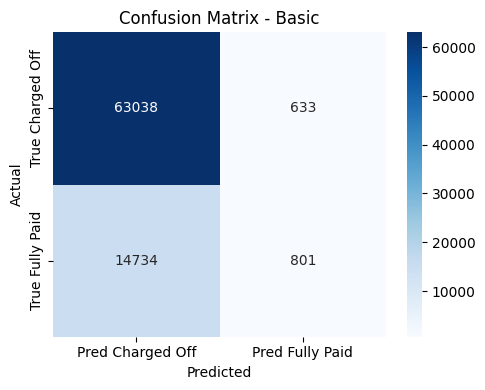


Key Metrics:
Accuracy                  : 0.8060

Class 0 (Charged Off):
 Precision               : 0.8105
 Recall                  : 0.9901
 F1-Score                : 0.8914

Class 1 (Fully Paid):
 Precision               : 0.5586
 Recall                  : 0.0516
 F1-Score                : 0.0944

ROC AUC: 0.7098


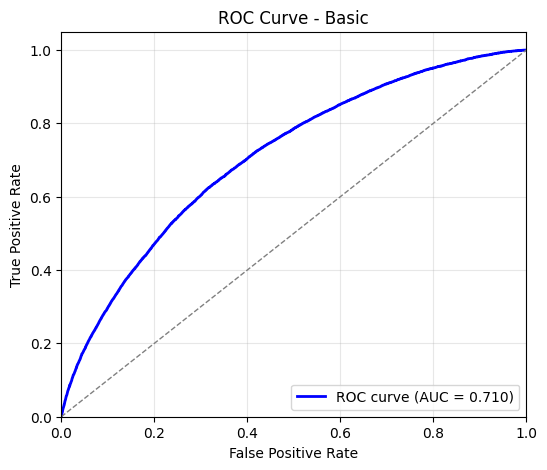

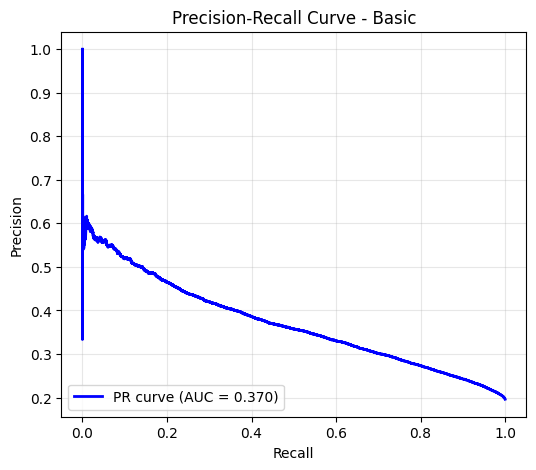


══════════════════════════════════════════════════════════════════════
MODEL: BALANCED
══════════════════════════════════════════════════════════════════════

Classification Report:
              precision    recall  f1-score   support

           0     0.8882    0.6320    0.7385     63671
           1     0.3088    0.6738    0.4235     15535

    accuracy                         0.6402     79206
   macro avg     0.5985    0.6529    0.5810     79206
weighted avg     0.7745    0.6402    0.6768     79206


Confusion Matrix:
[[40243 23428]
 [ 5067 10468]]


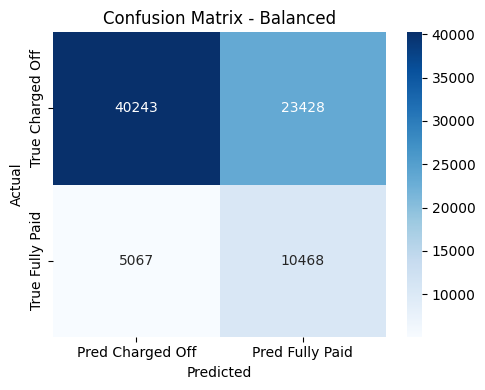


Key Metrics:
Accuracy                  : 0.6402

Class 0 (Charged Off):
 Precision               : 0.8882
 Recall                  : 0.6320
 F1-Score                : 0.7385

Class 1 (Fully Paid):
 Precision               : 0.3088
 Recall                  : 0.6738
 F1-Score                : 0.4235

ROC AUC: 0.7098


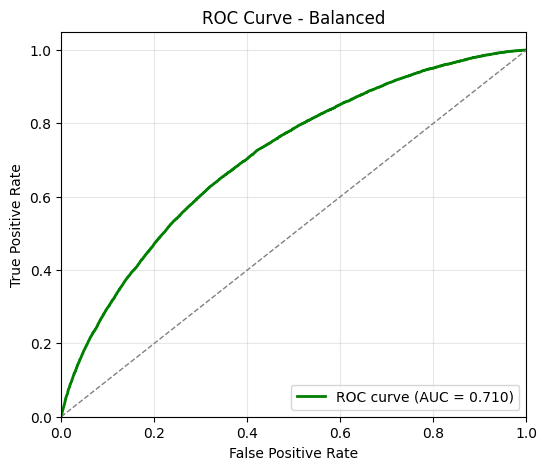

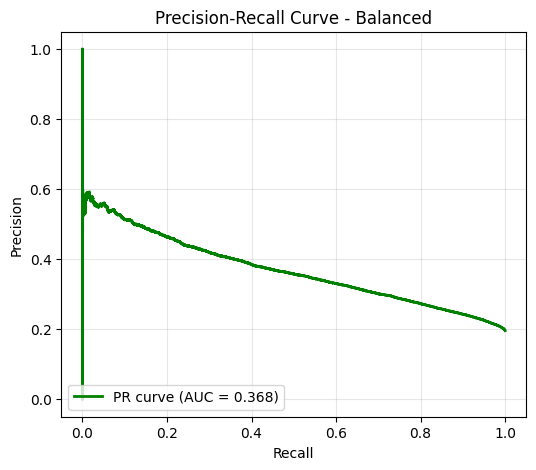


══════════════════════════════════════════════════════════════════════
MODEL: SMOTE
══════════════════════════════════════════════════════════════════════

Classification Report:
              precision    recall  f1-score   support

           0     0.8148    0.9278    0.8676     63671
           1     0.3143    0.1356    0.1894     15535

    accuracy                         0.7724     79206
   macro avg     0.5645    0.5317    0.5285     79206
weighted avg     0.7166    0.7724    0.7346     79206


Confusion Matrix:
[[59076  4595]
 [13429  2106]]


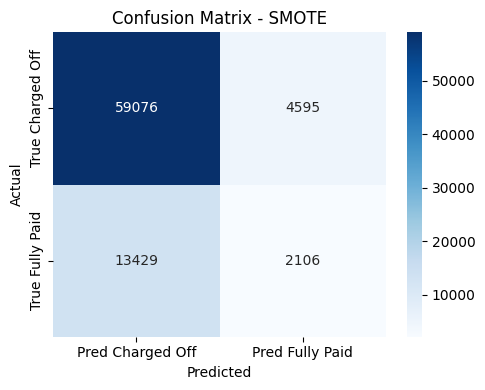


Key Metrics:
Accuracy                  : 0.7724

Class 0 (Charged Off):
 Precision               : 0.8148
 Recall                  : 0.9278
 F1-Score                : 0.8676

Class 1 (Fully Paid):
 Precision               : 0.3143
 Recall                  : 0.1356
 F1-Score                : 0.1894

ROC AUC: 0.6612


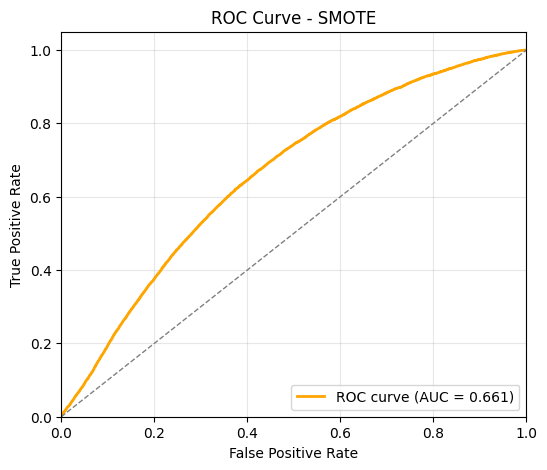

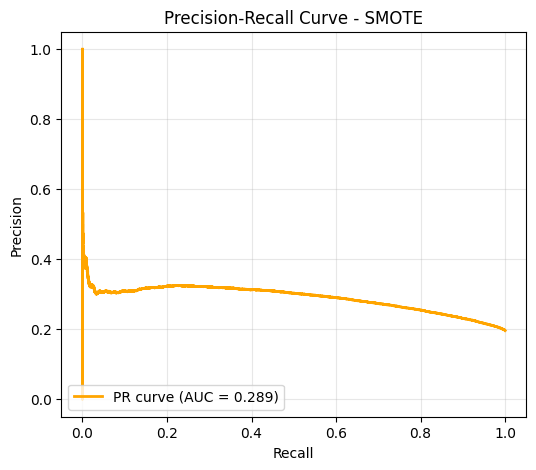


════════════════════════════════════════════════════════════════════════════════
FINAL MODEL COMPARISON
════════════════════════════════════════════════════════════════════════════════
   Model  Accuracy  Recall (Charged Off)  Precision (Charged Off)  F1 (Charged Off)  ROC AUC  PR AUC
   Basic    0.8060                0.9901                   0.8105            0.8914   0.7098  0.3696
Balanced    0.6402                0.6320                   0.8882            0.7385   0.7098  0.3682
   SMOTE    0.7724                0.9278                   0.8148            0.8676   0.6612  0.2888


In [84]:
# Dictionary of models
models = {"Basic": lr_basic, "Balanced": lr_balanced, "SMOTE": lr_smote}

# Colors for different models in plots
colors = {"Basic": "blue", "Balanced": "green", "SMOTE": "orange"}

# Store results for comparison table
results_summary = []

for name, mdl in models.items():
    print(f"\n{'═' * 70}")
    print(f"MODEL: {name.upper()}")
    print(f"{'═' * 70}\n")

    # Get predictions and probabilities
    y_pred = mdl.predict(X_test)
    y_proba = mdl.predict_proba(X_test)[:, 1]

    # 1. Classification Report
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits = 4))

    # 2. Confusion Matrix - Text + Visualization
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    plt.figure(figsize = (5,4))
    sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues',
                xticklabels = ['Pred Charged Off', 'Pred Fully Paid'],
                yticklabels = ['True Charged Off', 'True Fully Paid'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    # 3. Accuracy, Precision, Recall, F1 - both classes
    acc = accuracy_score(y_test, y_pred)
    prec_0 = precision_score(y_test, y_pred, pos_label=0)
    rec_0 = recall_score(y_test, y_pred, pos_label=0)
    f1_0 = f1_score(y_test, y_pred, pos_label=0)

    prec_1 = precision_score(y_test, y_pred, pos_label=1)
    rec_1 = recall_score(y_test, y_pred, pos_label=1)
    f1_1 = f1_score(y_test, y_pred, pos_label=1)

    print("\nKey Metrics:")
    print(f"Accuracy                  : {acc:.4f}")
    print("\nClass 0 (Charged Off):")
    print(f" Precision               : {prec_0:.4f}")
    print(f" Recall                  : {rec_0:.4f}")
    print(f" F1-Score                : {f1_0:.4f}")
    print("\nClass 1 (Fully Paid):")
    print(f" Precision               : {prec_1:.4f}")
    print(f" Recall                  : {rec_1:.4f}")
    print(f" F1-Score                : {f1_1:.4f}")

    # ROC AUC
    roc_auc = roc_auc_score(y_test, y_proba)
    print(f"\nROC AUC: {roc_auc:.4f}")

    # 4. ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize = (6, 5))
    plt.plot(fpr, tpr, color = colors[name], lw = 2, label = f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color = 'gray', lw = 1, linestyle = '--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {name}')
    plt.legend(loc = "lower right")
    plt.grid(True, alpha = 0.3)
    plt.show()

    # 5. Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)

    plt.figure(figsize = (6,5))
    plt.plot(recall, precision, color = colors[name], lw = 2,
             label = f'PR curve (AUC = {pr_auc:.3f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve - {name}')
    plt.legend(loc = "lower left")
    plt.grid(True, alpha = 0.3)
    plt.show()

    # Summary table
    results_summary.append({'Model': name, 'Accuracy': acc, 'Recall (Charged Off)': rec_0, 'Precision (Charged Off)': prec_0,
                            'F1 (Charged Off)': f1_0, 'ROC AUC': roc_auc, 'PR AUC': pr_auc})

# Final comparison table
print("\n" + "═"*80)
print("FINAL MODEL COMPARISON")
print("═"*80)
summary_df = pd.DataFrame(results_summary).round(4)
print(summary_df.to_string(index=False))

# **Part G: Questionnaire: (Q6-Q9)**

### **Q6: Thinking from a bank's perspective, which metric should our primary focus be on? ROC AUC, Precision, Recall, F1 Score**

- **Thinking from a bank's perspective, the primary focus should be on Recall because missing a defaulter (False Negative) will be far more costly (NPA, capital loss) than falsely rejecting a good borrower (False Positive – lost interest income).**

### **Q7: How does the gap in precision and recall affect the bank?**

- **High recall, low precision → Catches most defaulters but rejects many good borrowers (lost interest income).**
- **High precision, low recall → Approves more loans but misses many defaulters (higher NPA).**
- **Banks usually prioritize recall especially for the charged-off class while monitoring precision at the same time. So a good balance between precision and recall could be beneficial.**


### **Q8: Which were the features that heavily affected the outcome?**

In [85]:
import pandas as pd

# Dictionary of your fitted models
model_dict = {"Basic Model": lr_basic, "Balanced Model": lr_balanced, "SMOTE": lr_smote}

for model_name, model in model_dict.items():
    # Get coefficients
    coef = model.coef_[0]
    features = X_test.columns

    # Create DataFrame: feature + coefficient
    coef_df = pd.DataFrame({'Feature': features, 'Coefficient': coef})

    # Sort by absolute value (strongest impact first)
    coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
    coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False).drop(columns='Abs_Coefficient')

    print(f"\n{model_name} Model – Top features by absolute coefficient:")
    print(coef_df.head(3).to_string(index=False))

    print("\nInterpretation:")
    print("  Positive coefficient → higher value increases probability of Fully Paid (good outcome)")
    print("  Negative coefficient → higher value increases probability of Charged Off (bad outcome)\n")


Basic Model Model – Top features by absolute coefficient:
Feature  Coefficient
grade_G     3.620306
grade_F     3.382266
grade_E     2.968667

Interpretation:
  Positive coefficient → higher value increases probability of Fully Paid (good outcome)
  Negative coefficient → higher value increases probability of Charged Off (bad outcome)


Balanced Model Model – Top features by absolute coefficient:
Feature  Coefficient
grade_G     3.821214
grade_F     3.569658
grade_E     3.126581

Interpretation:
  Positive coefficient → higher value increases probability of Fully Paid (good outcome)
  Negative coefficient → higher value increases probability of Charged Off (bad outcome)


SMOTE Model – Top features by absolute coefficient:
     Feature  Coefficient
sub_grade_B2    -4.843719
sub_grade_C1    -4.840585
sub_grade_B1    -4.839501

Interpretation:
  Positive coefficient → higher value increases probability of Fully Paid (good outcome)
  Negative coefficient → higher value increases probabil

- **The strongest predictors of loan outcome (Fully Paid vs Charged Off) across all three models are the grade and sub_grade variables (especially the lower grades/sub-grades: G, F, E, C1, B2, etc.), which have the largest absolute coefficients.**

- **This is expected because grade/sub_grade are Lending Club's internal risk classifications that already summarize many other risk factors (interest rate, credit score, DTI, term length, etc.).**

- **After grade/sub_grade, the most consistently influential raw features are:**
1. int_rate —> higher interest rates strongly increase default probability.
2. term (especially 60 months) —> longer-term loans carry higher risk.
3. dti — higher debt-to-income ratio increases default likelihood.
4. annual_inc — higher income significantly improves repayment probability.
5. fico_range_low / fico_range_high — better credit scores reduce default risk.

### **Q9: Will the results be affected by geographical location? (Yes/No)**
- **State shows variation in default rates (example, higher in some states due to economic factors, legal differences, etc.)**

- **Including state as a categorical feature (or top states) can improve model performance slightly.**

# **Part H: Trade-off Questions**

### **Q1: How can we make sure that our model can detect real defaulters and there are less false positives? This is important as we can lose out on an opportunity to finance more individuals and earn interest on it.**

To maximize detection of real defaulters while keeping false positives as low as possible, we can adopt the following practical strategies:

**1. Choose the right model for high recall on Charged Off:
Upon comparison:**
- SMOTE model achieves the highest recall (0.9278) — it detects 92.78% of actual defaulters, missing very few.

- Basic model has extremely high recall (0.9901) but very low precision (0.8105) — it over-rejects good borrowers.

- Balanced model offers a good compromise (recall 0.6320, precision 0.8888) — better precision than SMOTE, acceptable recall.

> **Recommendation:** Start with SMOTE or Balanced model → both significantly outperform the Naive model on recall.

**2. Tune the decision threshold:**
- The default threshold is 0.5 in logistic regression. Lowering it to 0.35–0.45 could increase recall while still keeping precision reasonable.

**3. Use the Precision-Recall curve (PR AUC) to find the sweet spot:**
- SMOTE PR AUC = 0.2888 → curve drops quickly, so choose threshold where precision > 0.30–0.40.

- Balanced PR AUC = 0.3682 → better trade-off → threshold ~0.4–0.5 often optimal.

**4: Focus on PR curve over ROC**
- Because the dataset is imbalanced (~80:20), PR curve better shows the precision-recall tradeoff. ROC AUC (0.66–0.71 across models) looks similar, but PR AUC shows SMOTE/Balanced are stronger at high recall.

###  **Q2: Since NPA (non-performing asset) is a real problem in this industry, it’s important we play safe and shouldn’t disburse loans to anyone.**

- While NPAs are a critical risk, completely stopping disbursals is not viable. It would eliminate all interest revenue and make the lending business unsustainable.

- Use SMOTE or Balanced model (high recall on Charged Off: 0.93 and 0.63 respectively) with a very high approval threshold (0.80–0.90 probability of Fully Paid).

- Approve only the safest applicants, drastically reducing false negatives (approved defaulters).

- Add strict hard rules:
1. Reject below grade B/C
2. Reject DTI > 35–40
3. Reject FICO < 680–700
4. Reject recent bankruptcies/public records

- Accept lower approval volume (20–40% of applications) to achieve near-zero NPAs.

> **Conclusion:**
A “play safe” approach means high threshold + strict filters on the Balanced/SMOTE model — minimizing NPAs while still allowing profitable lending to the safest borrowers.

# **Part I: Insights and Recommendations:**

## **Key Insights:**

**1. Class Imbalance Dominates Baseline Performance**
- The Basic (Naive) model achieves high overall accuracy (80.6%) but extremely poor recall on Charged Off (0.99 → 0.63 in Balanced, 0.93 in SMOTE) — it heavily favors the majority class (Fully Paid).

**2. Imbalance Handling Significantly Improves Defaulter Detection**
- SMOTE gives the highest recall on Charged Off (92.78%) — catches most real defaulters.
- Balanced model offers the best precision-recall trade-off for Charged Off (precision 88.82%, recall 63.20%).
- Both outperform the naive model in F1-score for the minority class (0.87–0.74 vs 0.89 in naive, but naive precision is inflated by imbalance).

**3. ROC AUC is Stable, but PR AUC Shows True Value**
- ROC AUC remains similar (~0.66–0.71) across models — less sensitive to imbalance.
- PR AUC varies more (0.29–0.37) — SMOTE has lower PR AUC due to aggressive oversampling → highlights the precision cost

**4. Strong Multicollinearity in Features**
- loan_amnt and installment (~0.95) — high multicollinearity → drop one (installment recommended).
- open_acc and total_acc (~0.68) — related credit history features → consider keeping or creating ratio.
- pub_rec and pub_rec_bankruptcies (~0.70) — overlapping risk signals → keep pub_rec_bankruptcies (more specific).


## **Recommendations:**

1. **Primary Model Choice** → SMOTE for maximum defaulter detection (recall 92.78%) or Balanced for better overall trade-off (highest F1 for Charged Off at 0.7385)

2. **Threshold Tuning** → Use PR curve to lower threshold (0.35–0.45) on SMOTE/Balanced → push recall > 90% while keeping precision > 30–40%

3. **Feature Engineering** → Drop installment due to multicollinearity; consider open_acc/total_acc ratio; keep flags (mort_acc_flag, pub_rec_bankruptcies_flag) — they add value in SMOTE model

4. **Business Strategy**
Growth mode: SMOTE + threshold ~0.40 → high recall, more approvals, controlled NPAs. **Safety mode:** Balanced + threshold ~0.80 → very low NPA, fewer approvals but safer lending

5. **Final Choice** → Balanced model + adjustable threshold → best balance between catching defaulters and maintaining lending volume.

> **Customized Loan Products:** To improve product-market fit, create customized loan products for the most prevalent borrower classes.

> **Loan Term Structuring:** To reduce risk, give higher-grade loans more flexible terms while taking into account harsher conditions for lower-grade and longer-term loans.

> **Additional statistical analysis:** To make sure that lending strategies are data-driven, do further statistical tests to confirm the relevance of the connections and insights found.

> **Model Monitoring and Adjustment:** Keep an eye on credit scoring models and make necessary adjustments in response to shifts in borrower behavior and the state of the economy.